# 04. Business Insights: where the money comes from and where it leaks

**Project:** CRM funnel analysis, online IT school (Jul 2023 - May 2024) &nbsp;|&nbsp; **Audience:** business owner, sales and marketing leads
**Input:** `data/processed/deals_final_ue.pkl`, `data/processed/spend_cleaned.pkl` (outputs of notebooks 01-02)
**How to read:** every section starts with the question, shows one chart, and ends with the finding. Details and checks are in notebooks 02 (analytics) and 03 (unit economics, hypothesis).

![Metrics Tree](../assets/metric_tree.svg)

## Executive summary

| | |
| :--- | :--- |
| **Business is healthy** | EUR 3.35M revenue on a EUR 138K marketing budget (ROMI 2,323%). One paying student brings EUR 4,132 and costs EUR 171 to acquire: **CLTV / CAC = 24x** |
| **Growth is not about more traffic** | Marketing is 4.1% of revenue. A 10% cheaper acquisition adds about EUR 14K of margin, a 10% higher lead-to-student conversion adds about EUR 335K |
| **Conversion is the weak spot** | 18,250 leads give 810 paying students (C1 = 4.4% of leads). The same product converts at 1.8% for the CRM base and at 9.6% for Organic |
| **Google Ads is the most expensive channel** | 38.5% of the budget and 21% of revenue; a student from Google costs EUR 327, from Facebook EUR 163 |
| **Lead quality is falling while volume grows** | Between Aug-Nov 2023 and Dec 2023-Mar 2024 leads grew 50%, but the share of leads rated A-C dropped from 38.8% to 25.8% (about 20% in Feb-May 2024). Conversion held up (5.4% -> 5.0%), so the extra volume is lower-grade |
| **Speed of response is the controllable lever** | Median first response is hours, not minutes (see Section 3). A randomized 14-day test of a 30-minute first-contact rule is designed in notebook 03 |
| **Sales team** | Top 4 managers bring 59% of revenue; 9 managers with 1,612 leads (8.8%) closed nothing. Section 5 compares managers per active month and adjusts for the lead mix |

*Limitations:* COGS is not in the data (set to 0), so CLTV and CM are revenue-based. Revenue and paid months are accumulated up to 31 May 2024 (months studied so far fall from 9.7 for August leads to 1.9 for May leads, at a course length of about 10-11 months), so CLTV is a lower bound and recent cohorts look weaker than they are. Response-time effects are observational until the A/B test is run.

---
# 1. Setup and data check

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import FancyBboxPatch, Rectangle
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titleweight': 'bold', 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
})
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# --- Paths (notebook lives in notebooks/) ---
PROJECT_ROOT = Path().resolve().parent
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
ASSETS = PROJECT_ROOT / 'assets'
SAVE_FIGS = True                      # save every figure to assets/ (used by README.md)
if SAVE_FIGS:
    ASSETS.mkdir(exist_ok=True)

# --- Analysis settings ---
SYNC_START, SYNC_END = pd.Timestamp('2023-07-01'), pd.Timestamp('2024-05-31')   # common period of all datasets
UA_TOTAL = 17_250                     # unique potential clients (contacts), notebook 02, section 2.3
DIM = 'source'                        # dimension for the channel view: 'source' or 'campaign'
TOP_N = 10                            # channels shown separately (by revenue), the rest is grouped as 'Other'
MIN_LEADS_MONTH = 10                  # a manager counts as active in a month with at least this many leads
QUALIFIED = ['A - High', 'B - Medium', 'C - Low']   # quality grades treated as qualified leads

# --- Palette (same colors as in the metrics tree) ---
COL = {'green': '#43A047', 'red': '#E57373', 'blue': '#1E88E5', 'purple': '#7E57C2',
       'amber': '#F5A300', 'grey': '#9AA0A6', 'navy': '#34495E',
       'funnel': ['#6489B0', '#F29B45', '#6DAB65', '#7E57C2'],
       'cat': ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F', '#B07AA1']}

In [2]:
# --- Helpers ---
def say(text):
    """Show a Markdown finding under a chart."""
    display(Markdown(text))

def eur(x, digits=0):
    if pd.isna(x):
        return 'n/a'
    if abs(x) >= 1e6:
        return f'EUR {x / 1e6:,.2f}M'
    if abs(x) >= 1e4:
        return f'EUR {x / 1e3:,.0f}K'
    return f'EUR {x:,.{digits}f}'

def finish(fig, name):
    """Tighten, save for the README and show."""
    fig.tight_layout()
    if SAVE_FIGS:
        fig.savefig(ASSETS / f'{name}.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

def wilson(k, n, z=1.96):
    """95% Wilson interval for a share k / n."""
    k, n = np.asarray(k, float), np.asarray(n, float)
    with np.errstate(divide='ignore', invalid='ignore'):
        p = np.where(n > 0, k / n, 0.0)
        denom = 1 + z ** 2 / n
        centre = (p + z ** 2 / (2 * n)) / denom
        half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return np.where(n > 0, centre - half, 0.0), np.where(n > 0, centre + half, 0.0)

In [3]:
# --- Load ---
deals = pd.read_pickle(PROCESSED / 'deals_final_ue.pkl')
spend = pd.read_pickle(PROCESSED / 'spend_cleaned.pkl')

# --- Common period ---
spend = spend[(spend['spend_date'] >= SYNC_START) & (spend['spend_date'] <= SYNC_END)].copy()

# unique student key: contact_id; a paid deal without contact_id counts as a separate student (key = deal id)
deals['student_id'] = deals['contact_id'].fillna('deal_' + deals['deals_id'].astype(str)).astype(str)

# --- Core flags (same logic as notebooks 02 and 03) ---
deals['months'] = pd.to_numeric(deals['months_of_study'], errors='coerce').fillna(0)
deals['is_won'] = ((deals['stage'] == 'Payment Done') & (deals['months'] > 0)).fillna(False).astype(bool)
deals['Ri'] = pd.to_numeric(deals['Ri'], errors='coerce').fillna(0.0)
deals['rev_won'] = np.where(deals['is_won'], deals['Ri'], 0.0)          # revenue of paying students only
deals['qualified'] = deals['quality'].astype(str).isin(QUALIFIED)
deals['month'] = deals['created_date'].dt.to_period('M').dt.to_timestamp()   # lead cohort month

for c in ['source', 'campaign', 'product', 'payment_type', 'education_type', 'deal_owner_name']:
    deals[c] = deals[c].astype(str).str.strip().replace({'nan': 'Unknown', '<NA>': 'Unknown', '': 'Unknown'})
spend['month'] = spend['spend_date'].dt.to_period('M').dt.to_timestamp()
for c in ['source', 'campaign']:
    spend[c] = spend[c].astype(str).str.strip().replace({'nan': 'Unknown', '': 'Unknown'})

won = deals[deals['is_won']]
print(f'Deals: {len(deals):,} | spend rows in period: {len(spend):,} | period: {SYNC_START:%Y-%m-%d} - {SYNC_END:%Y-%m-%d}')

Deals: 18,250 | spend rows in period: 18,452 | period: 2023-07-01 - 2024-05-31


In [4]:
# --- Portfolio metrics (definitions: see glossary in notebooks 02 and 03) ---
def portfolio_kpis(won, n_leads, ua, ac, clicks):
    k = {'UA': ua, 'Leads': n_leads, 'Clicks': clicks, 'AC': ac}
    k['B'] = won['student_id'].nunique()            # unique paying students
    k['T'] = won['months'].sum()                    # transactions = paid months
    k['REV'] = won['Ri'].sum()
    k['C1'] = k['B'] / ua * 100                     # students / potential clients (metrics tree)
    k['C1_leads'] = k['B'] / n_leads * 100          # students / leads (used in channel and manager views)
    k['CPA'] = ac / ua
    k['CAC'] = ac / k['B']
    k['AOV'] = k['REV'] / k['T']                    # revenue per paid month
    k['APC'] = k['T'] / k['B']                      # paid months per student
    k['CLTV'] = k['AOV'] * k['APC']                 # = REV / B (COGS = 0)
    k['LTV'] = k['CLTV'] * k['C1'] / 100
    k['CM'] = k['UA'] * (k['LTV'] - k['CPA'])       # = REV - AC
    k['ROMI'] = (k['REV'] - ac) / ac * 100
    return k

K = portfolio_kpis(won, len(deals), UA_TOTAL, spend['spend'].sum(), spend['clicks'].sum())

# Control values from notebooks 02 and 03
control = {'Leads': 18_250, 'B': 810, 'T': 4_540, 'REV': 3_347_317.73, 'AOV': 737.29, 'AC': 138_152.50, 'Clicks': 468_577}
for name, expected in control.items():
    status = 'OK' if abs(K[name] - expected) < 0.5 else 'CHECK'
    print(f'{name:<7}{K[name]:>16,.2f}   control {expected:>14,.2f}   {status}')
print(f"CM = REV - AC: {abs(K['CM'] - (K['REV'] - K['AC'])) < 1}")

Leads         18,250.00   control      18,250.00   OK
B                810.00   control         810.00   OK
T              4,540.00   control       4,540.00   OK
REV        3,347,317.73   control   3,347,317.73   OK
AOV              737.29   control         737.29   OK
AC           138,152.50   control     138,152.50   OK
Clicks       468,577.00   control     468,577.00   OK
CM = REV - AC: True


---
# 2. The business in one page
**Question:** how big is the business, how efficient is acquisition, and where does revenue come from?

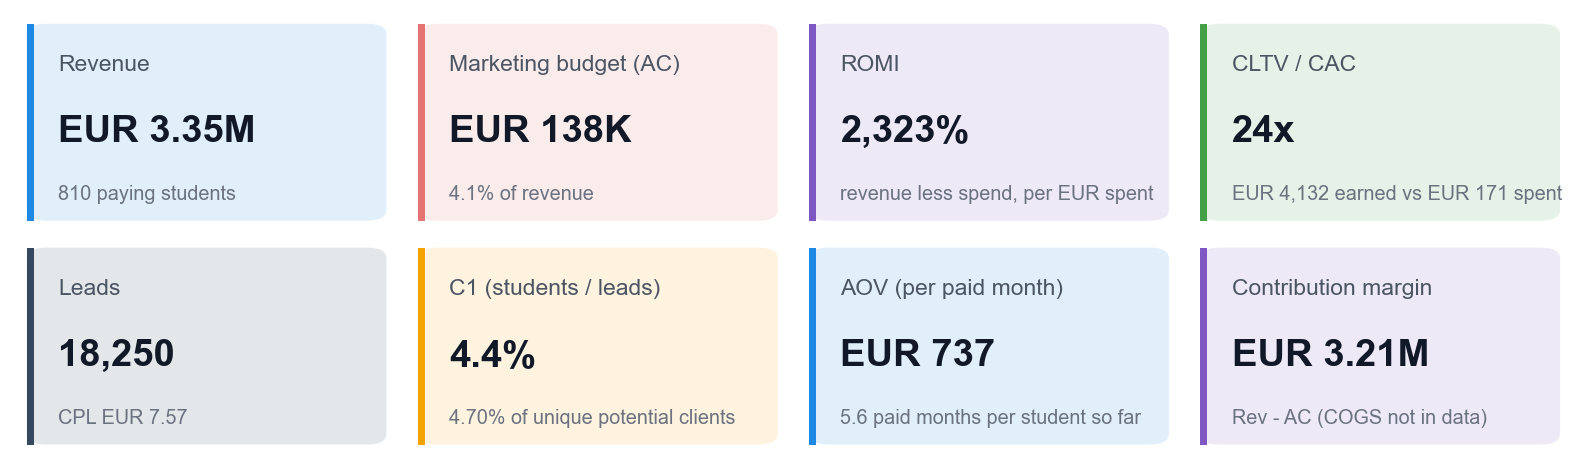

In [5]:
# --- 2.1 KPI tiles ---
def kpi_tiles(items, ncols=4, figsize=(15, 4.4)):
    nrows = int(np.ceil(len(items) / ncols))
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, ncols); ax.set_ylim(0, nrows); ax.axis('off')
    for i, (label, value, sub, color) in enumerate(items):
        r, c = divmod(i, ncols)
        x, y = c, nrows - 1 - r
        ax.add_patch(FancyBboxPatch((x + 0.04, y + 0.06), 0.92, 0.88, boxstyle='round,pad=0,rounding_size=0.05',
                                    fc=color, ec='none', alpha=0.13))
        ax.add_patch(Rectangle((x + 0.04, y + 0.06), 0.018, 0.88, fc=color, ec='none'))
        ax.text(x + 0.12, y + 0.76, label, fontsize=15, color='#4B5563', va='center')
        ax.text(x + 0.12, y + 0.46, value, fontsize=25, fontweight='bold', color='#111827', va='center')
        ax.text(x + 0.12, y + 0.18, sub, fontsize=13, color='#6B7280', va='center')
    return fig

tiles = [
    ('Revenue', eur(K['REV']), f"{K['B']:,} paying students", COL['blue']),
    ('Marketing budget (AC)', eur(K['AC']), f"{K['AC'] / K['REV'] * 100:.1f}% of revenue", COL['red']),
    ('ROMI', f"{K['ROMI']:,.0f}%", 'revenue less spend, per EUR spent', COL['purple']),
    ('CLTV / CAC', f"{K['CLTV'] / K['CAC']:.0f}x", f"EUR {K['CLTV']:,.0f} earned vs EUR {K['CAC']:,.0f} spent", COL['green']),
    ('Leads', f"{K['Leads']:,}", f"CPL EUR {K['AC'] / K['Leads']:.2f}", COL['navy']),
    ('C1 (students / leads)', f"{K['C1_leads']:.1f}%", f"{K['C1']:.2f}% of unique potential clients", COL['amber']),
    ('AOV (per paid month)', f"EUR {K['AOV']:,.0f}", f"{K['APC']:.1f} paid months per student so far", COL['blue']),
    ('Contribution margin', eur(K['CM']), 'Rev - AC (COGS not in data)', COL['purple']),
]
fig = kpi_tiles(tiles)
finish(fig, '04_01_kpi')

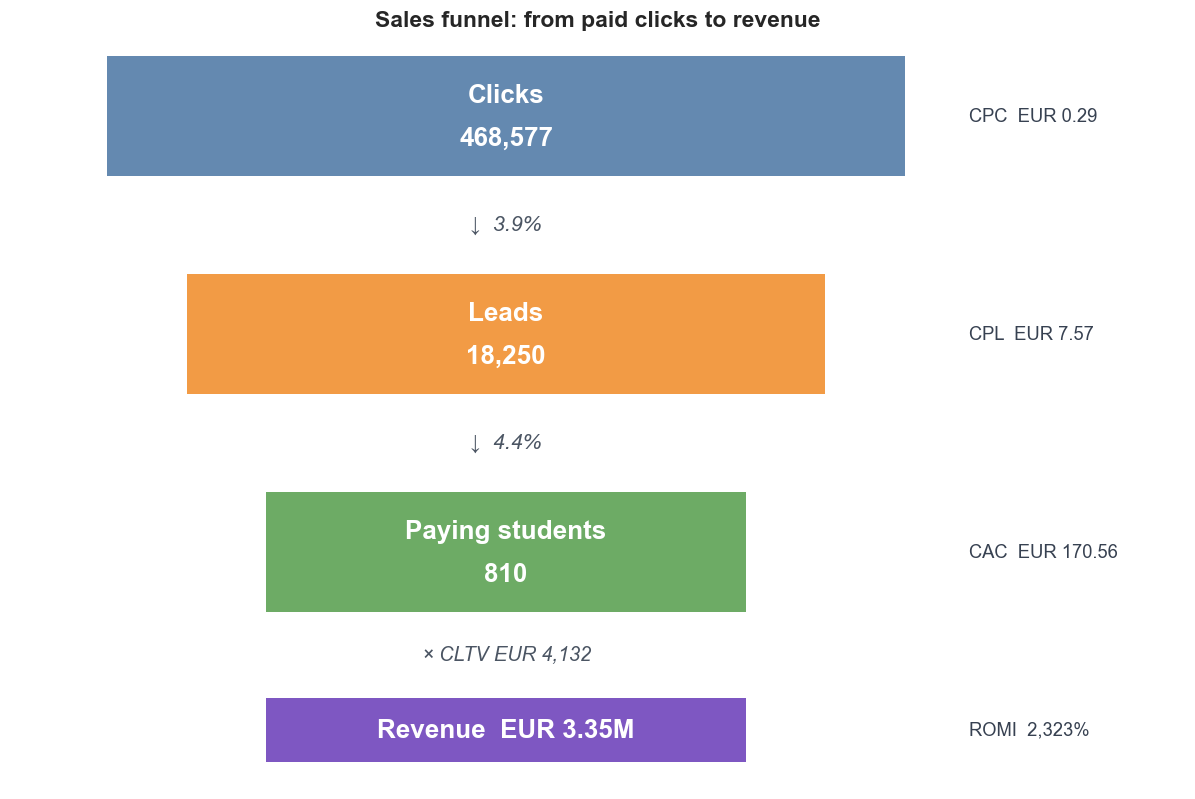

Only **3.9%** of paid clicks leave contact details and **4.4%** of leads pay. Every step is cheap (CPC EUR 0.29, CPL EUR 7.57), but the last step decides the price of a student (CAC EUR 171) and therefore the margin.

In [6]:
# --- 2.2 Funnel with revenue and cost per step ---
stages = [('Clicks', K['Clicks']), ('Leads', K['Leads']), ('Paying students', K['B'])]
widths = [1.0, 0.80, 0.60]
unit_cost = [K['AC'] / K['Clicks'], K['AC'] / K['Leads'], K['AC'] / K['B']]
unit_name = ['CPC', 'CPL', 'CAC']

fig, ax = plt.subplots(figsize=(11, 7.4))
ax.set_xlim(-0.62, 0.85); ax.set_ylim(-0.25, 7.0); ax.axis('off')
ys = [5.65, 3.55, 1.45]
for (name, val), w, y, c, uc, un in zip(stages, widths, ys, COL['funnel'], unit_cost, unit_name):
    ax.add_patch(Rectangle((-w / 2, y), w, 1.15, fc=c, ec='none'))
    ax.text(0, y + 0.77, name, ha='center', va='center', color='white', fontsize=17, fontweight='bold')
    ax.text(0, y + 0.36, f'{val:,.0f}', ha='center', va='center', color='white', fontsize=17, fontweight='bold')
    ax.text(0.58, y + 0.57, f'{un}  EUR {uc:,.2f}', ha='left', va='center', fontsize=12, color='#374151')
for i in range(2):
    conv = stages[i + 1][1] / stages[i][1] * 100
    ax.text(0, ys[i] - 0.47, f'\u2193  {conv:.1f}%', ha='center', va='center', fontsize=14, style='italic', color='#4B5563')
# revenue block
ax.text(0, 1.03, f"\u00d7 CLTV EUR {K['CLTV']:,.0f}", ha='center', va='center', fontsize=13, style='italic', color='#4B5563')
ax.add_patch(Rectangle((-0.30, 0.0), 0.60, 0.62, fc=COL['funnel'][3], ec='none'))
ax.text(0, 0.31, f"Revenue  {eur(K['REV'])}", ha='center', va='center', color='white', fontsize=17, fontweight='bold')
ax.text(0.58, 0.31, f"ROMI  {K['ROMI']:,.0f}%", ha='left', va='center', fontsize=12, color='#374151')
ax.set_title('Sales funnel: from paid clicks to revenue', fontsize=15, pad=6)
finish(fig, '04_02_funnel')

say(f"Only **{K['Leads'] / K['Clicks'] * 100:.1f}%** of paid clicks leave contact details and **{K['B'] / K['Leads'] * 100:.1f}%** of leads pay. "
    f"Every step is cheap (CPC EUR {unit_cost[0]:.2f}, CPL EUR {unit_cost[1]:.2f}), but the last step decides the price of a student "
    f"(CAC EUR {unit_cost[2]:.0f}) and therefore the margin.")

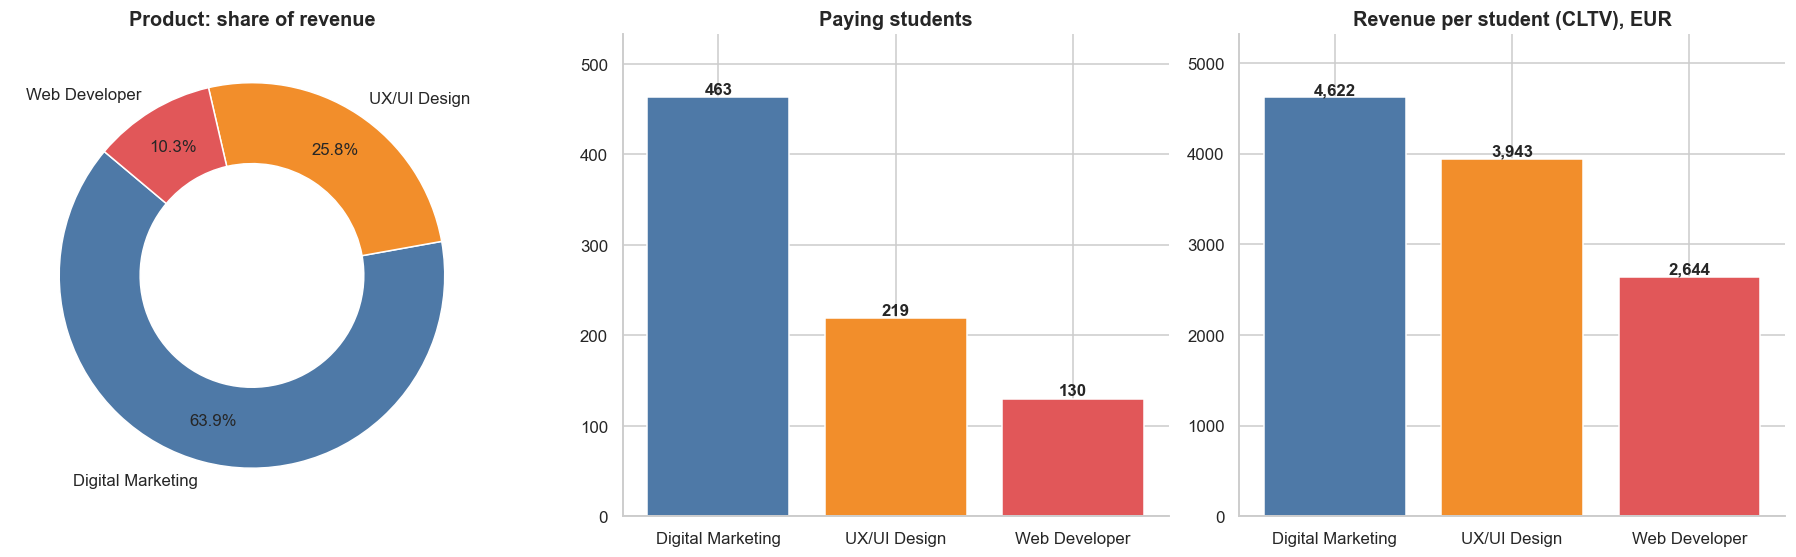

**Digital Marketing** brings 64% of revenue and 57% of students. A student of the most valuable product is worth EUR 4,622, of the least valuable EUR 2,644: the product mix matters as much as the number of students.

In [7]:
# --- 2.3 Products: revenue share, students, revenue per student ---
def group_table(df_won, col):
    g = df_won.groupby(col)
    t = pd.DataFrame({'REV': g['Ri'].sum(), 'B': g['student_id'].nunique(), 'T': g['months'].sum()})
    t['CLTV'] = t['REV'] / t['B']
    t['AOV'] = t['REV'] / t['T']
    t['REV_share'] = t['REV'] / t['REV'].sum() * 100
    return t.sort_values('REV', ascending=False)

def donut_with_bars(axes, table, colors, title):
    """Donut (revenue share) + bars (students) + bars (revenue per student)."""
    labels = table.index.tolist()
    colors = colors[:len(labels)]
    axes[0].pie(table['REV'], labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.78,
                wedgeprops=dict(width=0.42, edgecolor='white'), textprops={'fontsize': 11})
    axes[0].set_title(f'{title}: share of revenue')
    for ax, col, ttl, fmt in [(axes[1], 'B', 'Paying students', '{:,.0f}'), (axes[2], 'CLTV', 'Revenue per student (CLTV), EUR', '{:,.0f}')]:
        bars = ax.bar(labels, table[col], color=colors)
        for b_, v in zip(bars, table[col]):
            ax.text(b_.get_x() + b_.get_width() / 2, v, fmt.format(v), ha='center', va='bottom', fontweight='bold')
        ax.set_title(ttl); ax.set_ylim(0, table[col].max() * 1.15)
        ax.tick_params(axis='x', rotation=0)

prod = group_table(won, 'product')
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={'width_ratios': [1.1, 1, 1]})
donut_with_bars(axes, prod, COL['cat'], 'Product')
finish(fig, '04_03_products')

lead_p = prod.index[0]
say(f"**{lead_p}** brings {prod.loc[lead_p, 'REV_share']:.0f}% of revenue and {prod.loc[lead_p, 'B'] / prod['B'].sum() * 100:.0f}% of students. "
    f"A student of the most valuable product is worth EUR {prod['CLTV'].max():,.0f}, of the least valuable EUR {prod['CLTV'].min():,.0f}: "
    f"the product mix matters as much as the number of students.")

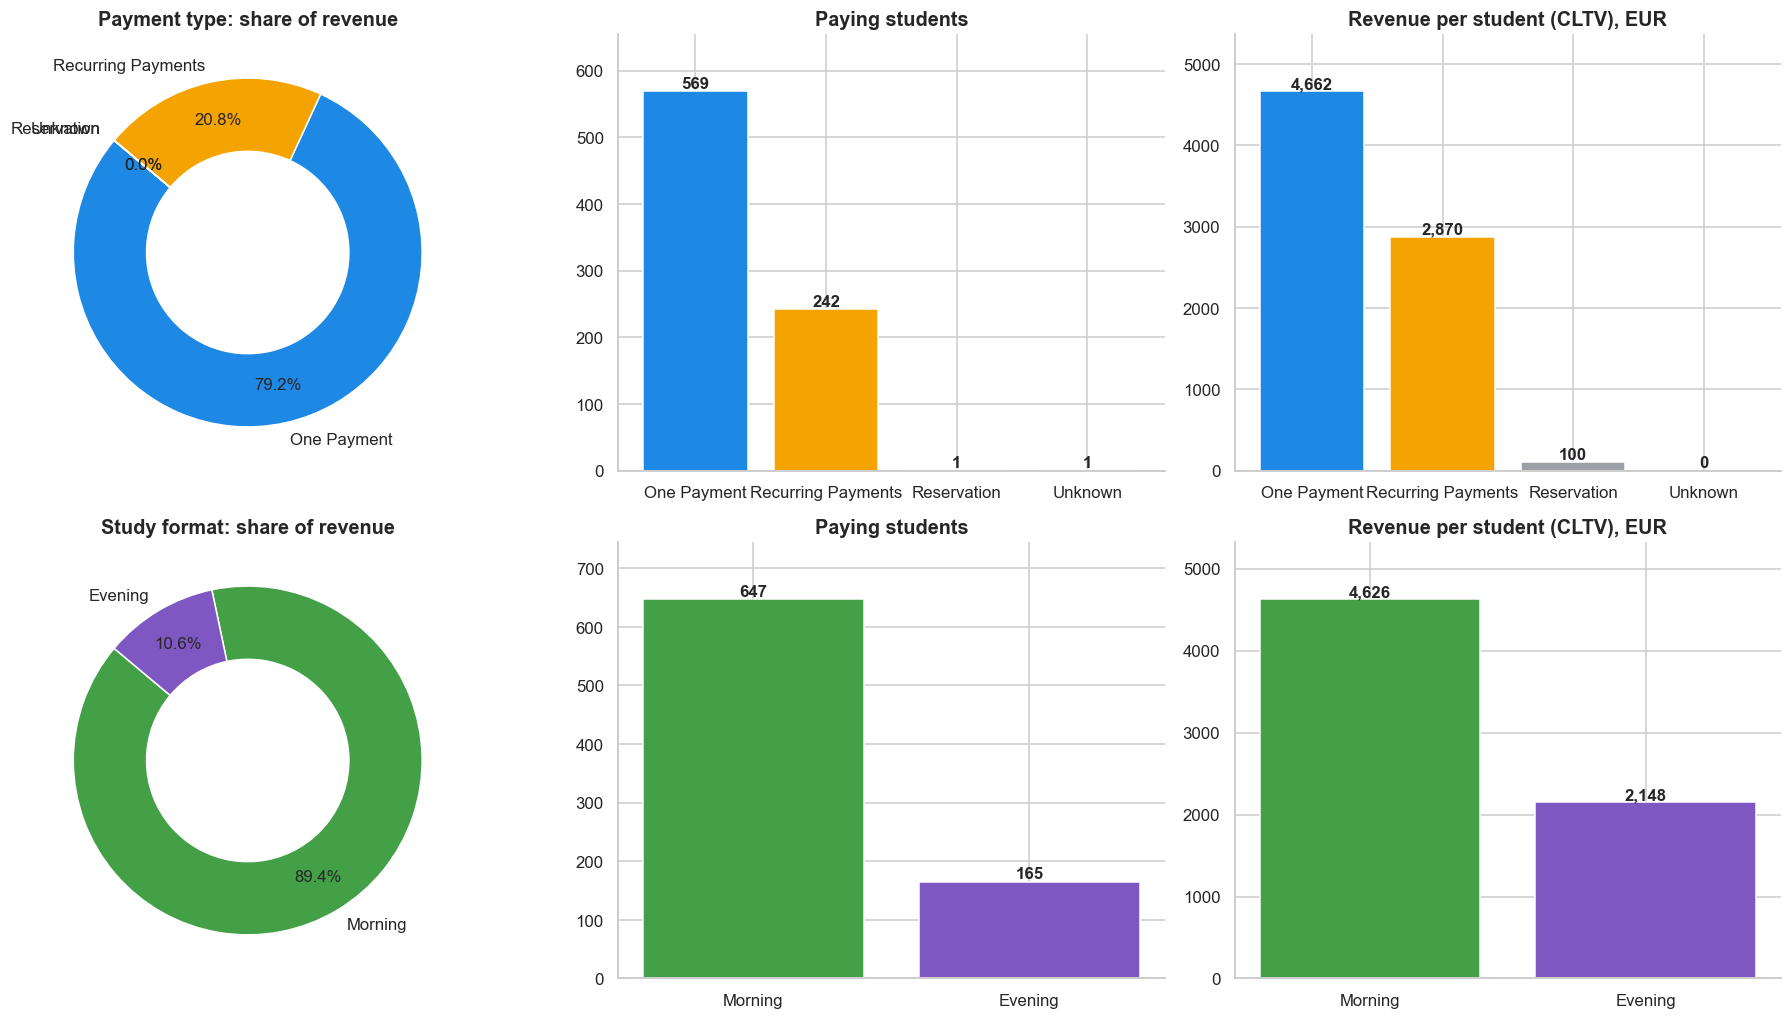

**One Payment** is 70% of students and 79% of revenue. Format **Morning** brings 89% of revenue. Instalment payers are still paying: their revenue per student is a lower bound.

In [8]:
# --- 2.4 Payment type and study format ---
pay = group_table(won, 'payment_type')
edu = group_table(won, 'education_type')

fig, axes = plt.subplots(2, 3, figsize=(17, 9.4), gridspec_kw={'width_ratios': [1.1, 1, 1]})
donut_with_bars(axes[0], pay, [COL['blue'], COL['amber'], COL['grey']], 'Payment type')
donut_with_bars(axes[1], edu, [COL['green'], COL['purple'], COL['grey']], 'Study format')
finish(fig, '04_04_payment_format')

p0 = pay.index[0]; e0 = edu.index[0]
say(f"**{p0}** is {pay.loc[p0, 'B'] / pay['B'].sum() * 100:.0f}% of students and {pay.loc[p0, 'REV_share']:.0f}% of revenue. "
    f"Format **{e0}** brings {edu.loc[e0, 'REV_share']:.0f}% of revenue. "
    f"Instalment payers are still paying: their revenue per student is a lower bound.")

---
# 3. Channels: who brings money, who converts, who is slow
**Question:** which channels carry the business, and where does the funnel leak?
The view below uses the main channels by revenue; the long tail is grouped as `Other`. The dimension is set in one place (`DIM`), so the same code can show campaigns instead of sources.

In [9]:
# --- Channel table ---
def with_channel(deals, spend, dim, top_n):
    """Add 'channel' = top_n values of `dim` by revenue, everything else = 'Other'."""
    d, s = deals.copy(), spend.copy()
    d['channel'] = d[dim]
    s['channel'] = s[dim]
    top = d.groupby('channel')['rev_won'].sum().nlargest(top_n).index
    d['channel'] = np.where(d['channel'].isin(top), d['channel'], 'Other')
    s['channel'] = np.where(s['channel'].isin(top), s['channel'], 'Other')
    return d, s

def channel_table(d, s):
    g = d.groupby('channel')
    w = d[d['is_won']].groupby('channel')
    t = pd.DataFrame({
        'Leads': g.size(),
        'B': w['student_id'].nunique(),
        'T': w['months'].sum(),
        'REV': g['rev_won'].sum(),
        'Qualified_rate': g['qualified'].mean() * 100,
        'SLA_med': g['SLA_hours'].median(),
        'No_call_share': g['SLA_hours'].apply(lambda x: x.isna().mean() * 100),
    }).fillna({'B': 0, 'T': 0})
    t = t.join(s.groupby('channel').agg(AC=('spend', 'sum'), Clicks=('clicks', 'sum'))).fillna({'AC': 0, 'Clicks': 0})
    nz = lambda x: x.replace(0, np.nan)
    t['C1'] = t['B'] / t['Leads'] * 100
    t['CPL'] = (t['AC'] / t['Leads']).where(t['AC'] > 0)
    t['CAC'] = (t['AC'] / nz(t['B'])).where(t['AC'] > 0)
    t['ROMI'] = ((t['REV'] - t['AC']) / t['AC'] * 100).where(t['AC'] > 0)
    t['AOV'] = t['REV'] / nz(t['T'])
    t['APC'] = t['T'] / nz(t['B'])
    t['CLTV'] = t['REV'] / nz(t['B'])
    for c in ['REV', 'Leads', 'AC']:
        t[f'{c}_share'] = t[c] / t[c].sum() * 100
    return t.sort_values('REV', ascending=False)

d_ch, s_ch = with_channel(deals, spend, DIM, TOP_N)
ch = channel_table(d_ch, s_ch)
SLA_ALL = deals['SLA_hours'].median()
display(ch[['Leads', 'B', 'REV', 'AC', 'C1', 'Qualified_rate', 'SLA_med', 'CAC', 'ROMI', 'CLTV']].round(1))

,Leads,B,REV,AC,C1,Qualified_rate,SLA_med,CAC,ROMI,CLTV
channel,,,,,,,,,,
Facebook Ads,4409,192,"897,577.10","31,318.40",4.40,32.00,5.50,163.10,"2,766.00","4,674.90"
Google Ads,3879,163,"706,275.50","53,231.60",4.20,26.90,5.20,326.60,"1,226.80","4,333.00"
Organic,1416,136,"546,140.50",0.00,9.60,38.10,4.40,NaN,NaN,"4,015.70"
SMM,1501,86,"285,267.00","6,414.50",5.70,30.70,3.50,74.60,"4,347.20","3,317.10"
Youtube Ads,1514,52,"201,484.80","13,695.00",3.40,27.20,6.10,263.40,"1,371.20","3,874.70"
Tiktok Ads,1795,52,"196,195.00","10,988.90",2.90,25.50,5.60,211.30,"1,685.40","3,773.00"
Bloggers,1028,39,"162,766.80","13,309.00",3.80,28.40,11.20,341.30,"1,123.00","4,173.50"
Telegram posts,950,38,"147,365.20","6,266.20",4.00,29.80,3.60,164.90,"2,251.80","3,878.00"
Webinar,281,26,"107,915.90","2,320.70",9.30,31.30,66.20,89.30,"4,550.10","4,150.60"


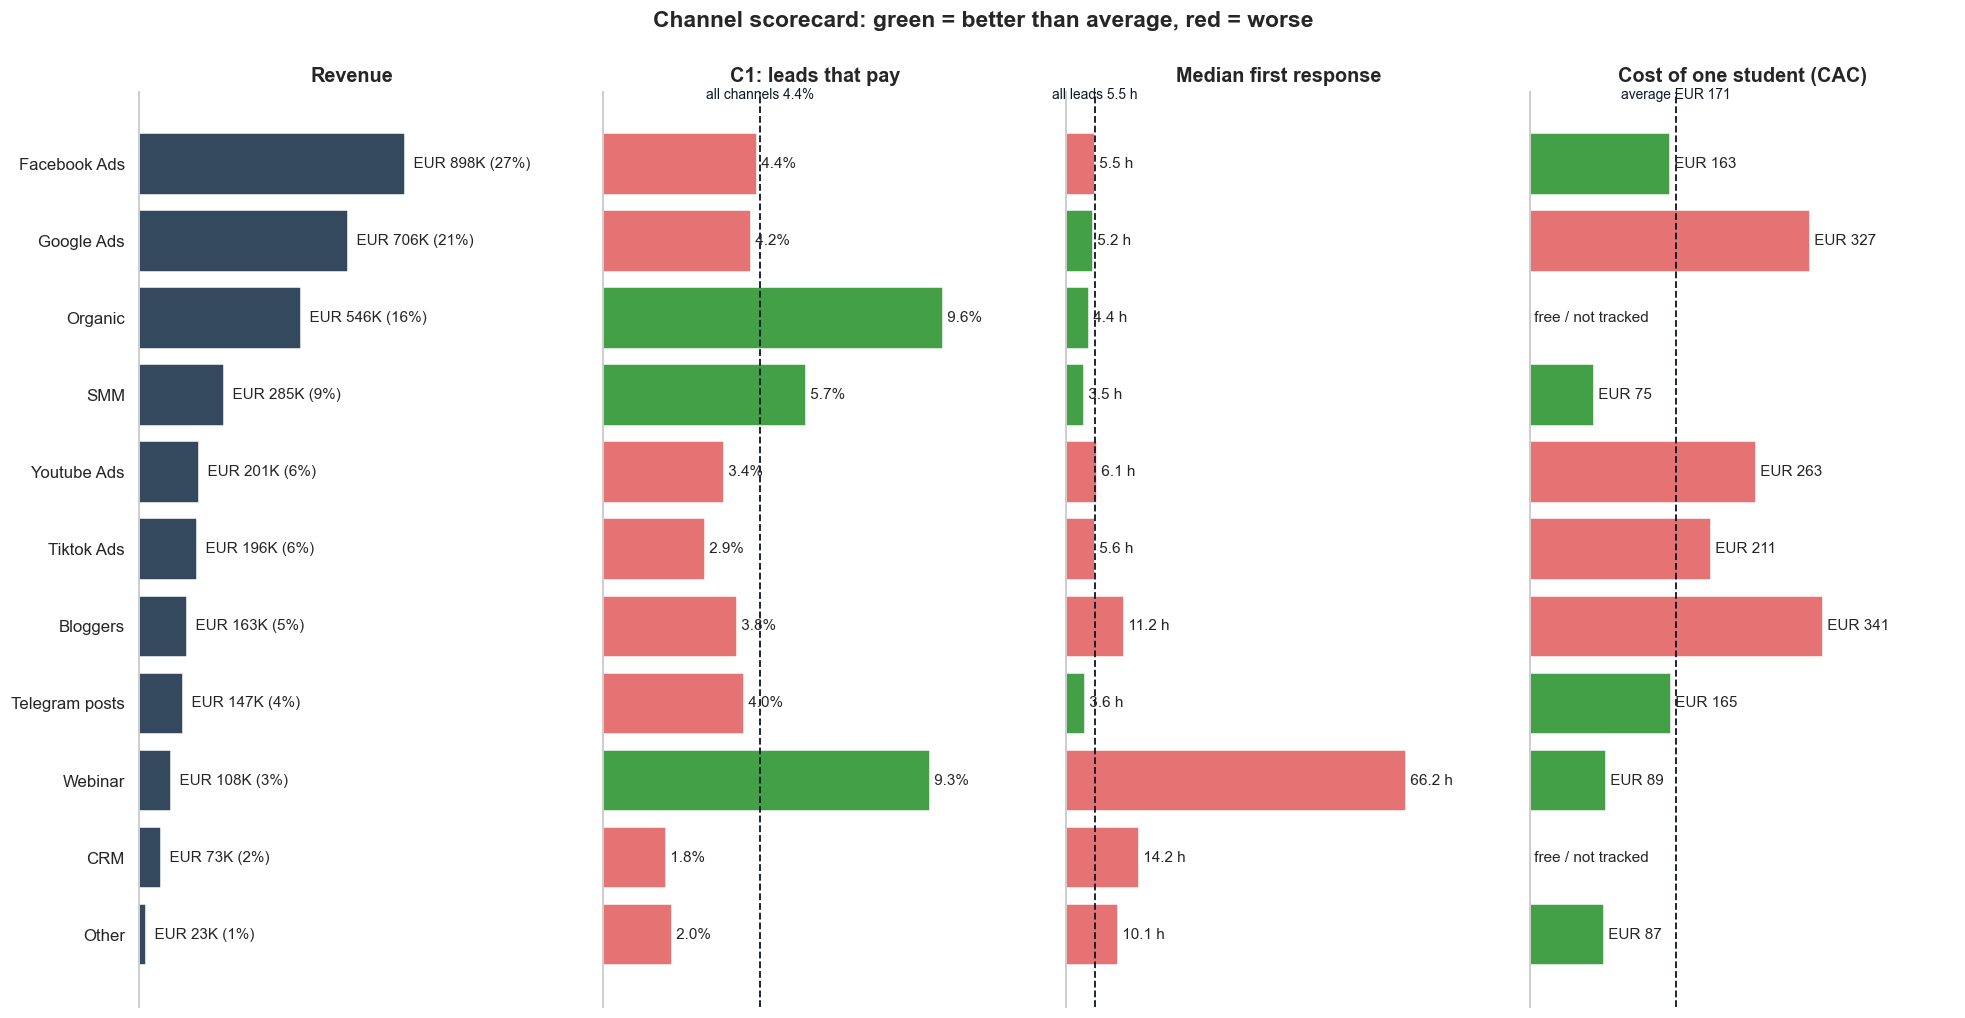

- **Facebook Ads** is the revenue leader (27% of revenue) but converts 4.35% of leads against 4.44% overall; median first response is 5.5 h.
- Best conversion among channels with 500+ leads: **Organic** (9.6%); worst: **CRM** (1.8%), a 5.4x gap.
- Slowest first response: **Webinar** (66.2 h at the median).
- The most expensive student comes from **Bloggers** (EUR 341), the cheapest paid one from **SMM** (EUR 75).

In [10]:
# --- 3.1 Channel dashboard: revenue | conversion | speed | cost of a student ---
order = ch.index.tolist()
y = np.arange(len(order))
fig, axes = plt.subplots(1, 4, figsize=(18, 0.62 * len(order) + 2.4), sharey=True)

# revenue
ax = axes[0]
ax.barh(y, ch['REV'], color=COL['navy'])
for yi, (v, s_) in enumerate(zip(ch['REV'], ch['REV_share'])):
    ax.text(v, yi, f'  {eur(v)} ({s_:.0f}%)', va='center', fontsize=10)
ax.set_xlim(0, ch['REV'].max() * 1.6); ax.set_title('Revenue'); ax.set_xticks([])

# conversion
ax = axes[1]
cols_c1 = [COL['green'] if v >= K['C1_leads'] else COL['red'] for v in ch['C1']]
ax.barh(y, ch['C1'], color=cols_c1)
ax.axvline(K['C1_leads'], color='#111827', ls='--', lw=1.2)
ax.text(K['C1_leads'], -0.85, f"all channels {K['C1_leads']:.1f}%", ha='center', fontsize=9, color='#111827')
for yi, v in enumerate(ch['C1']):
    ax.text(v, yi, f' {v:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, ch['C1'].max() * 1.25); ax.set_title('C1: leads that pay'); ax.set_xticks([])

# speed
ax = axes[2]
cols_sla = [COL['red'] if v > SLA_ALL else COL['green'] for v in ch['SLA_med'].fillna(0)]
ax.barh(y, ch['SLA_med'].fillna(0), color=cols_sla)
ax.axvline(SLA_ALL, color='#111827', ls='--', lw=1.2)
ax.text(SLA_ALL, -0.85, f'all leads {SLA_ALL:.1f} h', ha='center', fontsize=9, color='#111827')
for yi, v in enumerate(ch['SLA_med']):
    ax.text(0 if pd.isna(v) else v, yi, ' n/a' if pd.isna(v) else f' {v:.1f} h', va='center', fontsize=10)
ax.set_xlim(0, max(ch['SLA_med'].max(), SLA_ALL) * 1.25); ax.set_title('Median first response'); ax.set_xticks([])

# cost of a student
ax = axes[3]
cac = ch['CAC']
cap = K['CAC'] * 3                                   # outliers are clipped, the true value stays in the label
cols_cac = [COL['red'] if v > K['CAC'] else COL['green'] for v in cac.fillna(0)]
ax.barh(y, cac.fillna(0).clip(upper=cap), color=cols_cac)
ax.axvline(K['CAC'], color='#111827', ls='--', lw=1.2)
ax.text(K['CAC'], -0.85, f"average EUR {K['CAC']:.0f}", ha='center', fontsize=9, color='#111827')
for yi, v in enumerate(cac):
    ax.text(0 if pd.isna(v) else min(v, cap), yi, ' free / not tracked' if pd.isna(v) else f' EUR {v:,.0f}', va='center', fontsize=10)
ax.set_xlim(0, min(cac.max(), cap) * 1.45); ax.set_title('Cost of one student (CAC)'); ax.set_xticks([])

axes[0].set_yticks(y); axes[0].set_yticklabels(order); axes[0].invert_yaxis()
for a in axes:
    a.grid(False); a.spines['bottom'].set_visible(False)
fig.suptitle('Channel scorecard: green = better than average, red = worse', fontsize=15, fontweight='bold', y=1.0)
finish(fig, '04_05_channel_dashboard')

lead = ch.index[0]
big = ch[ch['Leads'] >= 500]
best, worst = big['C1'].idxmax(), big['C1'].idxmin()
slow = ch['SLA_med'].idxmax()
paid = ch[ch['AC'] > 0]
say(f"- **{lead}** is the revenue leader ({ch.loc[lead, 'REV_share']:.0f}% of revenue) but converts {ch.loc[lead, 'C1']:.2f}% of leads against {K['C1_leads']:.2f}% overall; "
    f"median first response is {ch.loc[lead, 'SLA_med']:.1f} h.\n"
    f"- Best conversion among channels with 500+ leads: **{best}** ({ch.loc[best, 'C1']:.1f}%); worst: **{worst}** ({ch.loc[worst, 'C1']:.1f}%), a {ch.loc[best, 'C1'] / max(ch.loc[worst, 'C1'], 0.01):.1f}x gap.\n"
    f"- Slowest first response: **{slow}** ({ch.loc[slow, 'SLA_med']:.1f} h at the median).\n"
    f"- The most expensive student comes from **{paid['CAC'].idxmax()}** (EUR {paid['CAC'].max():,.0f}), the cheapest paid one from **{paid['CAC'].idxmin()}** (EUR {paid['CAC'].min():,.0f}).")

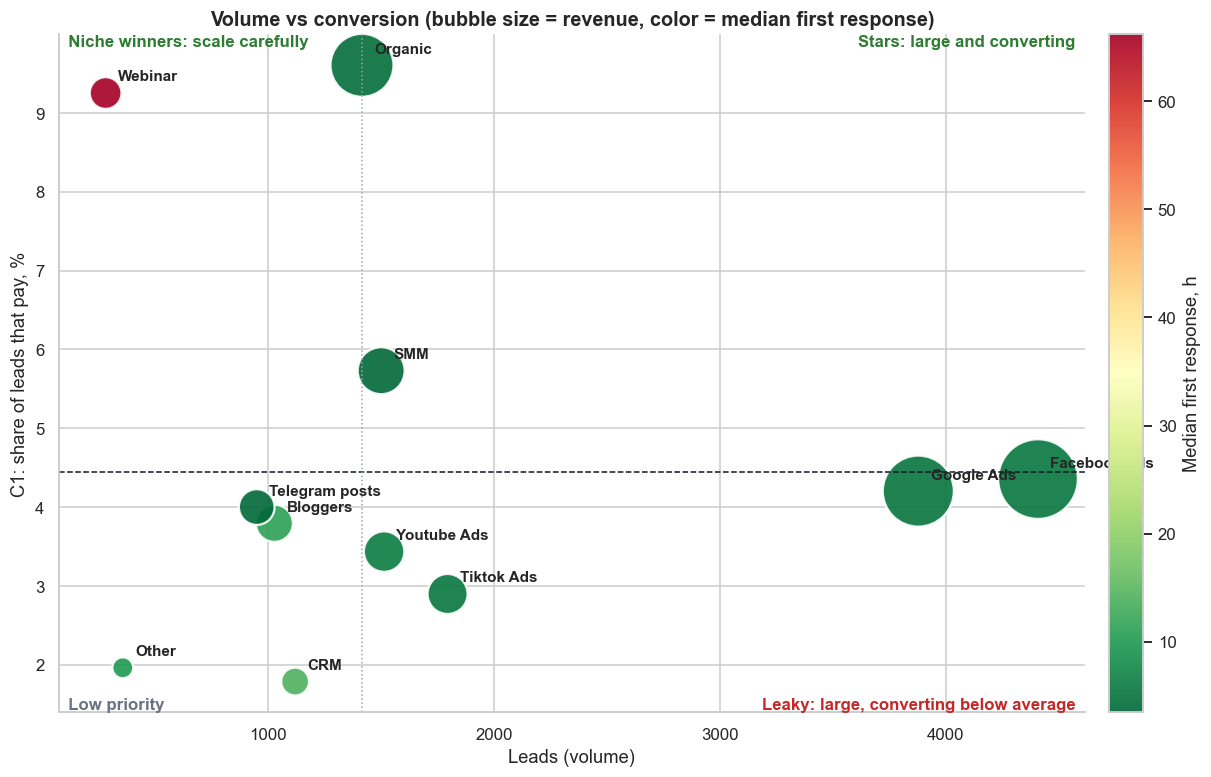

In [11]:
# --- 3.2 Volume vs conversion vs speed ---
fig, ax = plt.subplots(figsize=(12, 7.2))
sizes = ch['REV'] / ch['REV'].max() * 2600 + 120
sc = ax.scatter(ch['Leads'], ch['C1'], s=sizes, c=ch['SLA_med'].fillna(SLA_ALL), cmap='RdYlGn_r',
                edgecolor='white', linewidth=1.5, alpha=0.9)
for name, r in ch.iterrows():
    ax.annotate(name, (r['Leads'], r['C1']), xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold')
ax.axhline(K['C1_leads'], color='#111827', ls='--', lw=1)
ax.axvline(ch['Leads'].median(), color='#9CA3AF', ls=':', lw=1)
xl, yl = ax.get_xlim(), ax.get_ylim()
ax.text(xl[1], yl[1], 'Stars: large and converting  ', ha='right', va='top', fontsize=11, color='#2E7D32', fontweight='bold')
ax.text(xl[1], yl[0], 'Leaky: large, converting below average  ', ha='right', va='bottom', fontsize=11, color='#C62828', fontweight='bold')
ax.text(xl[0], yl[1], '  Niche winners: scale carefully', ha='left', va='top', fontsize=11, color='#2E7D32', fontweight='bold')
ax.text(xl[0], yl[0], '  Low priority', ha='left', va='bottom', fontsize=11, color='#6B7280', fontweight='bold')
ax.set_xlabel('Leads (volume)'); ax.set_ylabel('C1: share of leads that pay, %')
ax.set_title('Volume vs conversion (bubble size = revenue, color = median first response)')
cb = fig.colorbar(sc, ax=ax, pad=0.02); cb.set_label('Median first response, h')
finish(fig, '04_06_channel_bubble')

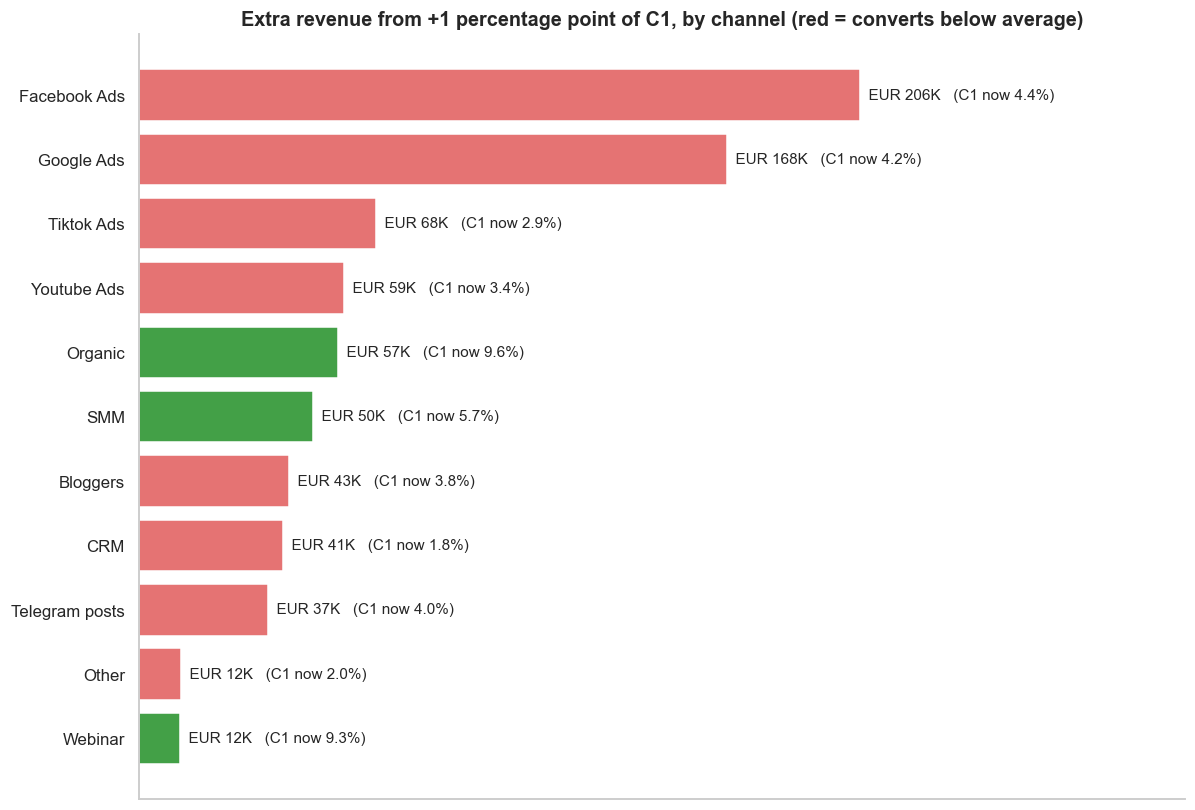

+1 percentage point of conversion is worth about **EUR 751K** across all channels. Most of it sits in **Facebook Ads** (EUR 206K) and **Google Ads** (EUR 168K): these are the first places for a response-speed pilot because they carry the volume.

In [12]:
# --- 3.3 Where does +1 percentage point of C1 pay most? ---
gain = (ch['Leads'] * 0.01 * ch['CLTV'].fillna(K['CLTV'])).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(11, 0.5 * len(gain) + 2))
colors = [COL['red'] if ch.loc[n, 'C1'] < K['C1_leads'] else COL['green'] for n in gain.index]
ax.barh(gain.index, gain.values, color=colors)
for yi, (n, v) in enumerate(gain.items()):
    ax.text(v, yi, f"  {eur(v)}   (C1 now {ch.loc[n, 'C1']:.1f}%)", va='center', fontsize=10)
ax.set_xlim(0, gain.max() * 1.45); ax.set_xticks([])
ax.set_title('Extra revenue from +1 percentage point of C1, by channel (red = converts below average)')
ax.grid(False)
finish(fig, '04_07_c1_upside')

g1, g2 = gain.index[-1], gain.index[-2]
say(f"+1 percentage point of conversion is worth about **{eur(gain.sum())}** across all channels. "
    f"Most of it sits in **{g1}** ({eur(gain[g1])}) and **{g2}** ({eur(gain[g2])}): "
    f"these are the first places for a response-speed pilot because they carry the volume.")

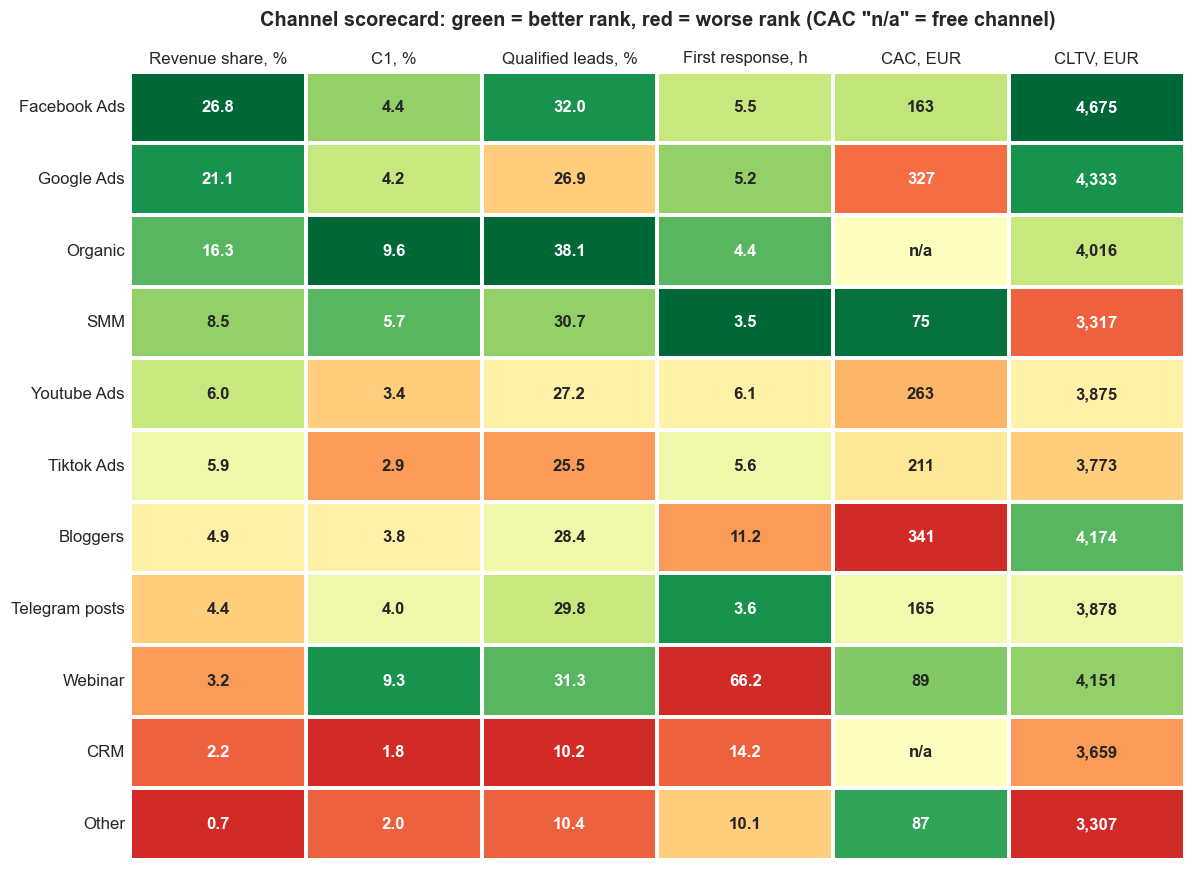

In [13]:
# --- 3.4 Heatmap scorecard (color = rank among channels, text = value) ---
sc_cols = {'REV_share': 'Revenue share, %', 'C1': 'C1, %', 'Qualified_rate': 'Qualified leads, %',
           'SLA_med': 'First response, h', 'CAC': 'CAC, EUR', 'CLTV': 'CLTV, EUR'}
lower_is_better = ['SLA_med', 'CAC']
sc_vals = ch[list(sc_cols)].copy()
score = sc_vals.rank(pct=True)
for c in lower_is_better:
    score[c] = 1 - score[c] + 1 / len(score)          # invert so that green = good
score = score.clip(0, 1).fillna(0.5)                  # n/a (free channels) shown neutral
ann = sc_vals.copy().astype(object)
for c in sc_vals:
    ann[c] = sc_vals[c].map(lambda v: 'n/a' if pd.isna(v) else (f'{v:,.0f}' if c in ('CAC', 'CLTV') else f'{v:,.1f}'))
fig, ax = plt.subplots(figsize=(11, 0.55 * len(sc_vals) + 2))
sns.heatmap(score.values, annot=ann.values, fmt='', cmap='RdYlGn', vmin=0, vmax=1, cbar=False,
            xticklabels=list(sc_cols.values()), yticklabels=sc_vals.index, linewidths=2.5, linecolor='white',
            annot_kws={'fontsize': 11, 'fontweight': 'bold'}, ax=ax)
ax.xaxis.tick_top(); ax.tick_params(axis='x', rotation=0, length=0); ax.tick_params(axis='y', length=0, rotation=0)
ax.set_title('Channel scorecard: green = better rank, red = worse rank (CAC "n/a" = free channel)', pad=30)
finish(fig, '04_08_scorecard')

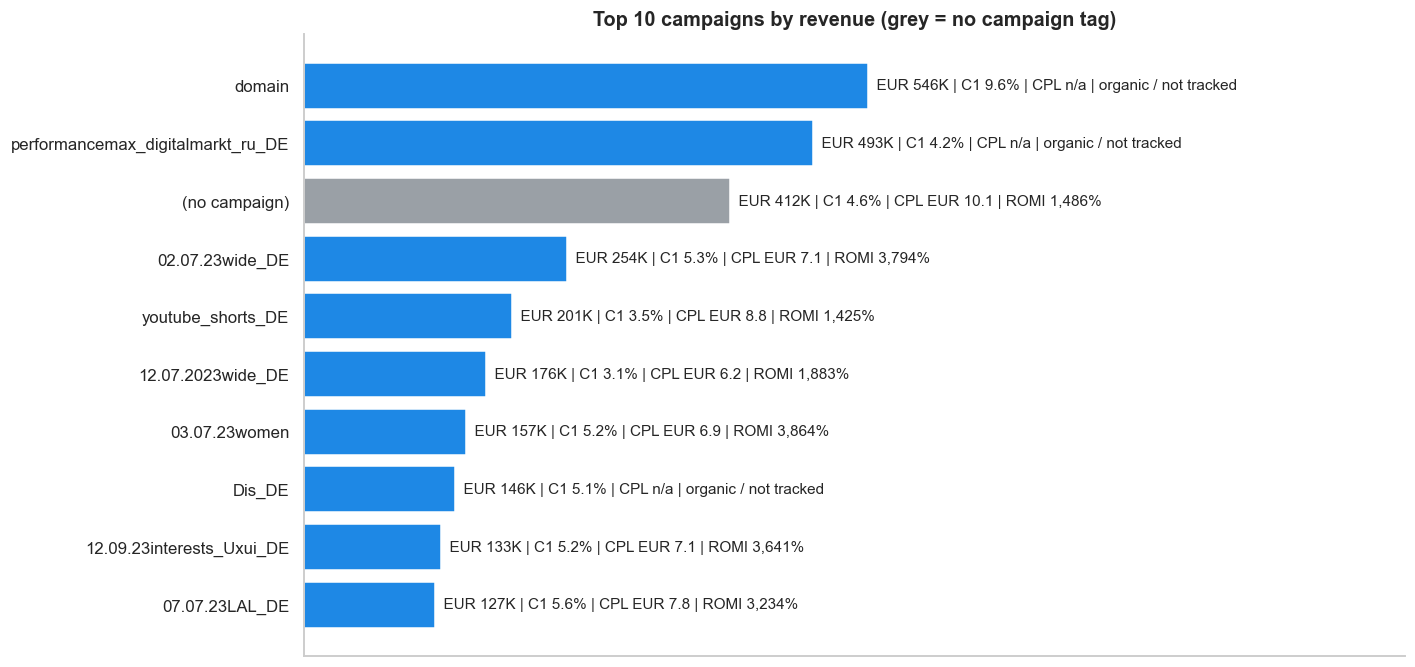

The top 10 campaigns bring 79% of revenue. Best ROMI among tagged campaigns: **03.07.23women** (3,864%); highest C1: **domain** (9.6%). Revenue without a campaign tag: 12%, a data-capture gap.

In [14]:
# --- 3.5 Campaign drill-down: top 10 campaigns by revenue ---
d_cp, s_cp = with_channel(deals, spend, 'campaign', 10)
cp = channel_table(d_cp, s_cp)
cp = cp.drop(index='Other', errors='ignore').head(10)

fig, ax = plt.subplots(figsize=(13, 6.2))
ypos = np.arange(len(cp))
colors = [COL['grey'] if n.startswith('(') else COL['blue'] for n in cp.index]
ax.barh(ypos, cp['REV'], color=colors)
for yi, (n, r) in enumerate(cp.iterrows()):
    romi = 'organic / not tracked' if pd.isna(r['ROMI']) else f"ROMI {r['ROMI']:,.0f}%"
    ax.text(r['REV'], yi, f"  {eur(r['REV'])} | C1 {r['C1']:.1f}% | CPL {'n/a' if pd.isna(r['CPL']) else 'EUR %.1f' % r['CPL']} | {romi}", va='center', fontsize=10)
ax.set_yticks(ypos); ax.set_yticklabels(cp.index); ax.invert_yaxis()
ax.set_xlim(0, cp['REV'].max() * 1.95); ax.set_xticks([]); ax.grid(False)
ax.set_title('Top 10 campaigns by revenue (grey = no campaign tag)')
finish(fig, '04_09_campaigns')

tagged = cp[~cp.index.str.startswith('(')]
say(f"The top 10 campaigns bring {cp['REV'].sum() / K['REV'] * 100:.0f}% of revenue. "
    f"Best ROMI among tagged campaigns: **{tagged['ROMI'].idxmax()}** ({tagged['ROMI'].max():,.0f}%); "
    f"highest C1: **{tagged['C1'].idxmax()}** ({tagged['C1'].max():.1f}%). "
    f"Revenue without a campaign tag: {(deals.loc[deals['campaign'].str.startswith('('), 'rev_won'].sum() / K['REV'] * 100):.0f}%, a data-capture gap.")

---
# 4. Speed of response
**Question:** does the time to the first call go together with conversion?
*Observational view: fast calls may simply go to better leads. This is exactly why notebook 03 designs a randomized test.*

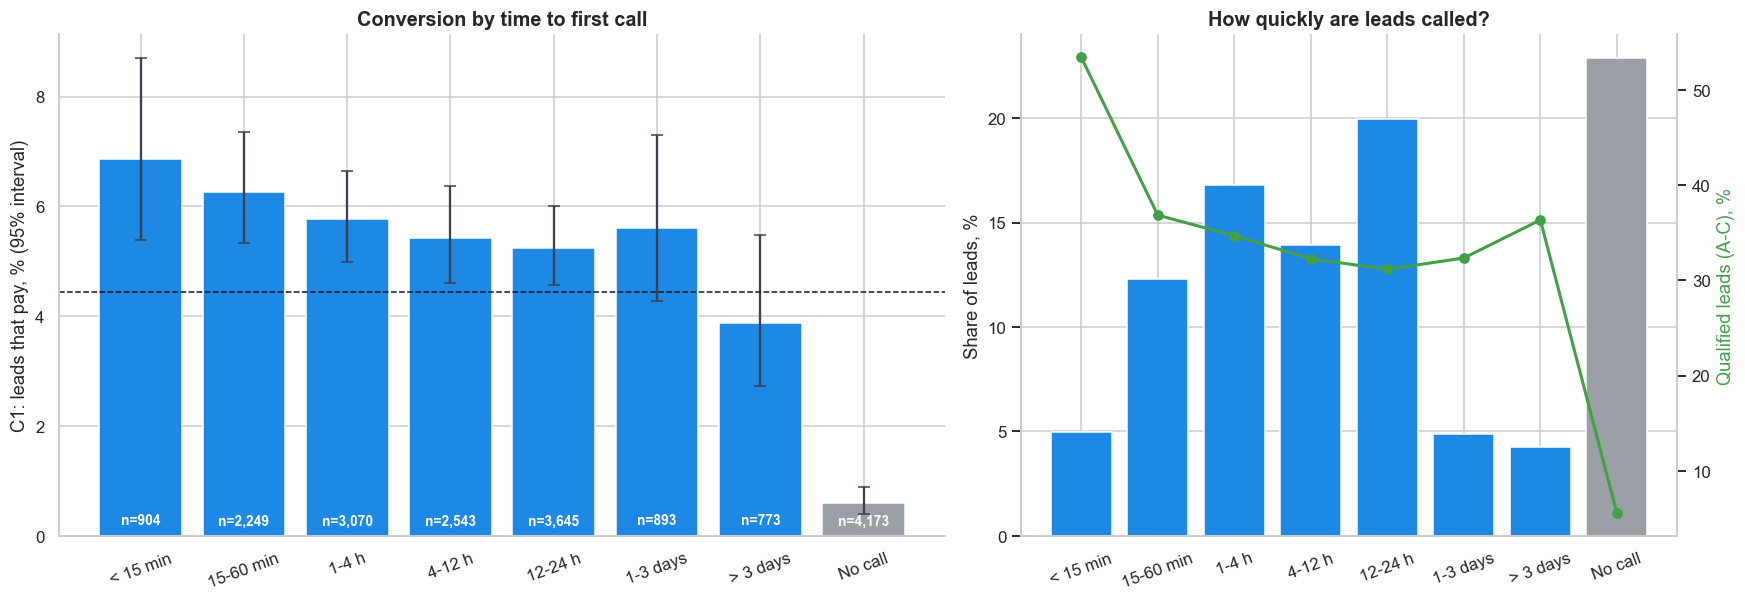

Median first response is **5.5 h**; only **22%** of called leads were reached within an hour, and **23%** of leads were never called. Leads reached within an hour pay 6.4% of the time, leads reached after more than 24 h 4.8%. Faster calls go together with better conversion, but this does not prove cause and effect.

In [15]:
# --- 4.1 First response time vs conversion ---
bins = [-0.001, 0.25, 1, 4, 12, 24, 72, np.inf]
labels = ['< 15 min', '15-60 min', '1-4 h', '4-12 h', '12-24 h', '1-3 days', '> 3 days']
deals['sla_bucket'] = pd.cut(deals['SLA_hours'], bins=bins, labels=labels).astype(object)
deals.loc[deals['SLA_hours'].isna(), 'sla_bucket'] = 'No call'
order_b = labels + ['No call']
sb = deals.groupby('sla_bucket').agg(Leads=('is_won', 'size'), Won=('is_won', 'sum'), Qualified=('qualified', 'mean')).reindex(order_b).fillna(0)
sb['C1'] = sb['Won'] / sb['Leads'].replace(0, np.nan) * 100
lo, hi = wilson(sb['Won'], sb['Leads'])
sb['lo'], sb['hi'] = lo * 100, hi * 100
sb['share'] = sb['Leads'] / sb['Leads'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), gridspec_kw={'width_ratios': [1.35, 1]})
ax = axes[0]
colors = [COL['blue']] * len(labels) + [COL['grey']]
ax.bar(order_b, sb['C1'].fillna(0), color=colors, yerr=[(sb['C1'] - sb['lo']).fillna(0), (sb['hi'] - sb['C1']).fillna(0)],
       capsize=4, ecolor='#374151')
for xi, (v, n) in enumerate(zip(sb['C1'].fillna(0), sb['Leads'])):
    ax.text(xi, 0.15, f'n={n:,.0f}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')
ax.axhline(K['C1_leads'], color='#111827', ls='--', lw=1)
ax.set_ylabel('C1: leads that pay, % (95% interval)'); ax.set_title('Conversion by time to first call')
ax.tick_params(axis='x', rotation=20)
ax = axes[1]
ax.bar(order_b, sb['share'], color=colors)
ax.set_ylabel('Share of leads, %'); ax.set_title('How quickly are leads called?')
ax.tick_params(axis='x', rotation=20)
ax2 = ax.twinx(); ax2.plot(order_b, sb['Qualified'] * 100, color=COL['green'], marker='o', lw=2)
ax2.set_ylabel('Qualified leads (A-C), %', color=COL['green']); ax2.grid(False); ax2.spines['right'].set_visible(True)
finish(fig, '04_10_sla')

fast = deals['SLA_hours'] <= 1
slow = deals['SLA_hours'] > 24
say(f"Median first response is **{SLA_ALL:.1f} h**; only **{fast.sum() / deals['SLA_hours'].notna().sum() * 100:.0f}%** of called leads were reached within an hour, "
    f"and **{deals['SLA_hours'].isna().mean() * 100:.0f}%** of leads were never called. "
    f"Leads reached within an hour pay {deals.loc[fast, 'is_won'].mean() * 100:.1f}% of the time, leads reached after more than 24 h {deals.loc[slow, 'is_won'].mean() * 100:.1f}%. "
    f"Faster calls go together with better conversion, but this does not prove cause and effect.")

---
# 5. Dynamics by month
**Question:** are volume, lead quality, conversion and cost stable over time?
Months are lead cohorts (by creation date). The last two months are hatched: payments take a median of 17.5 days (75% pay within 43 days), so their conversion is still maturing. Revenue is not plotted as a trend on purpose: revenue and paid months are accumulated up to the data cutoff, so recent cohorts always look smaller (see the bottom-right chart).

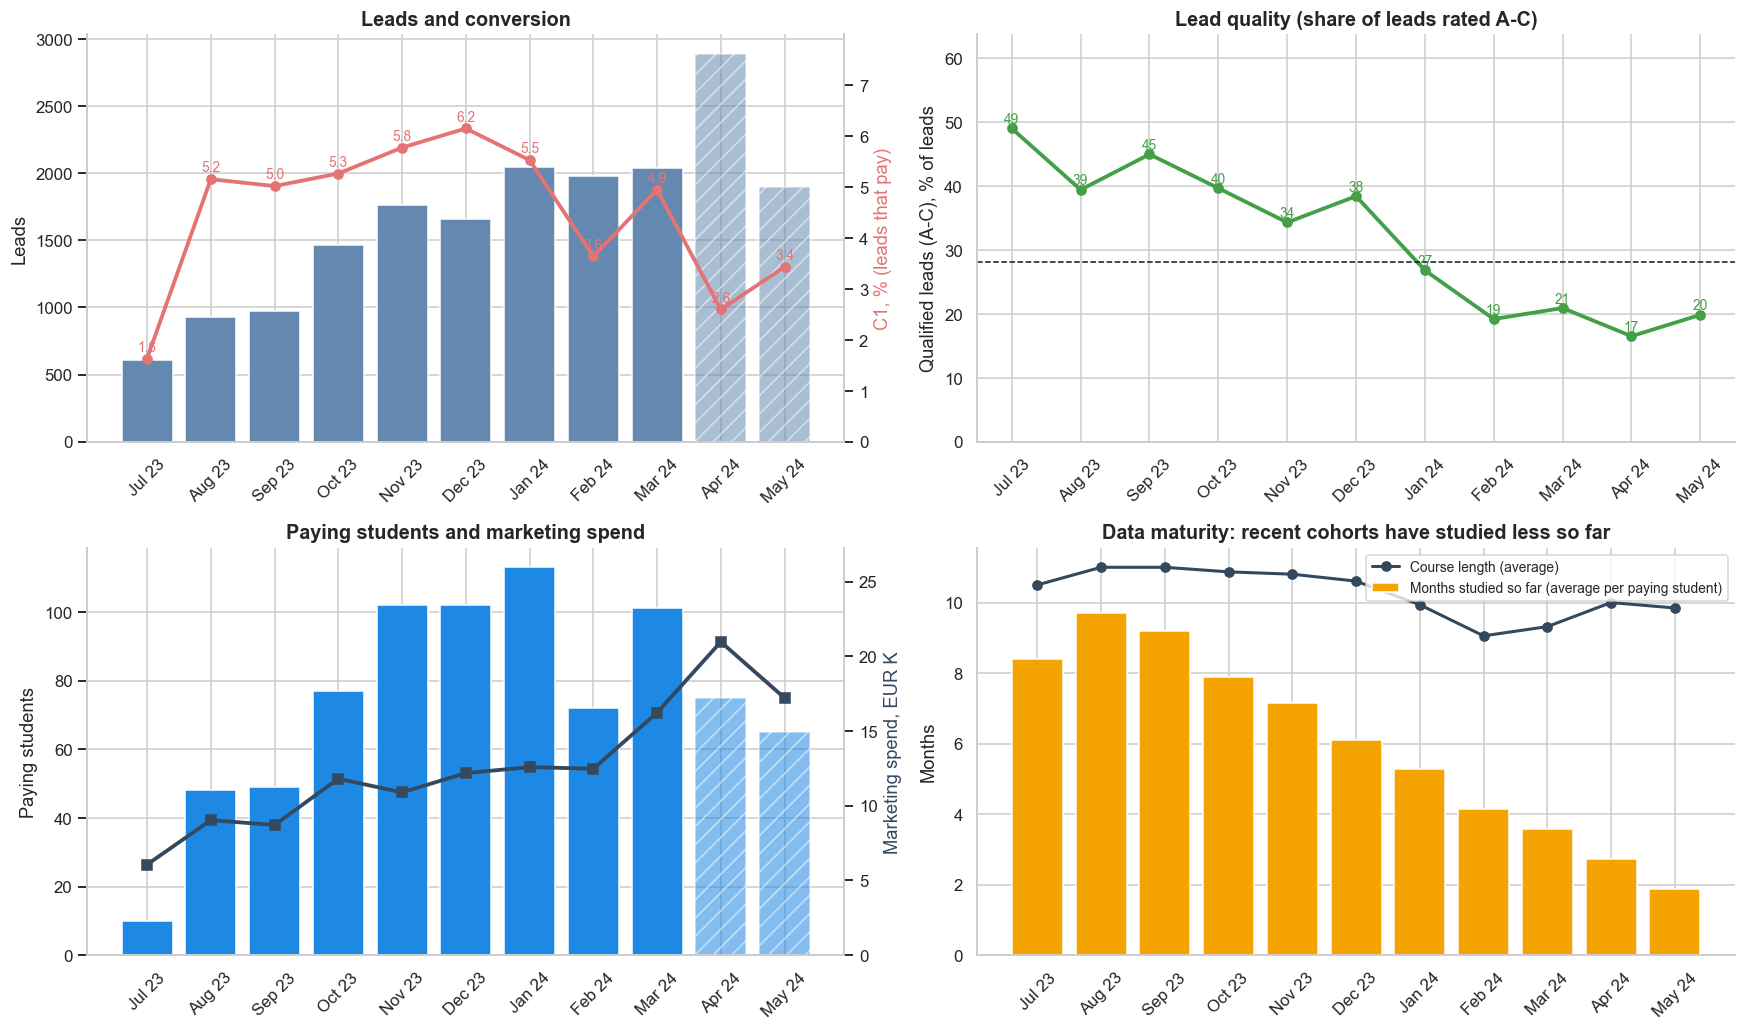

Comparing Aug-Nov 2023 with Dec-Mar 2024: leads **+50%**, C1 **5.37% -> 5.03%**, share of qualified leads **38.8% -> 25.8%**. Volume grew much faster than quality: the extra leads convert, but the rating of the flow got weaker (check the rating process and lead sources before reading this as a market change).

Data maturity: months studied so far fall from **9.7** (Aug 2023 leads) to **1.9** (May 2024 leads) at a course length of about **10** months. Revenue and paid months of recent cohorts are still accumulating, so cohort revenue is not read as a trend and CLTV is a lower bound.

In [16]:
# --- 5.1 Monthly dynamics ---
months = pd.date_range(SYNC_START, SYNC_END, freq='MS')
mo = deals.groupby('month').agg(Leads=('is_won', 'size'), Won=('is_won', 'sum'), Qualified=('qualified', 'mean')).reindex(months).fillna(0)
mo['AC'] = spend.groupby('month')['spend'].sum().reindex(months).fillna(0)
mo['C1'] = mo['Won'] / mo['Leads'].replace(0, np.nan) * 100
mo['Qualified'] = mo['Qualified'] * 100
mo['Months_studied'] = won.groupby('month')['months'].mean().reindex(months)
mo['Course'] = pd.to_numeric(won['course_duration'], errors='coerce').groupby(won['month']).mean().reindex(months)
labels_m = [m.strftime('%b %y') for m in months]
immature = np.arange(len(months)) >= len(months) - 2

def hatch_last(bars):
    for b_, imm in zip(bars, immature):
        if imm:
            b_.set_hatch('//'); b_.set_alpha(0.55)

fig, axes = plt.subplots(2, 2, figsize=(16, 9.5))
ax = axes[0, 0]
hatch_last(ax.bar(labels_m, mo['Leads'], color=COL['funnel'][0]))
ax.set_ylabel('Leads'); ax.set_title('Leads and conversion')
ax2 = ax.twinx(); ax2.plot(labels_m, mo['C1'], color=COL['red'], marker='o', lw=2.5)
ax2.set_ylabel('C1, % (leads that pay)', color=COL['red']); ax2.set_ylim(0, max(mo['C1'].max() * 1.3, 1))
ax2.grid(False); ax2.spines['right'].set_visible(True)
for x_, v in zip(labels_m, mo['C1']):
    ax2.text(x_, v + 0.15, f'{v:.1f}', ha='center', fontsize=9, color=COL['red'])

ax = axes[0, 1]
ax.plot(labels_m, mo['Qualified'], color=COL['green'], marker='o', lw=2.5)
ax.axhline(deals['qualified'].mean() * 100, color='#111827', ls='--', lw=1)
ax.set_ylim(0, mo['Qualified'].max() * 1.3); ax.set_ylabel('Qualified leads (A-C), % of leads')
ax.set_title('Lead quality (share of leads rated A-C)')
for x_, v in zip(labels_m, mo['Qualified']):
    ax.text(x_, v + 0.8, f'{v:.0f}', ha='center', fontsize=9, color=COL['green'])

ax = axes[1, 0]
hatch_last(ax.bar(labels_m, mo['Won'], color=COL['blue']))
ax.set_ylabel('Paying students'); ax.set_title('Paying students and marketing spend')
ax3 = ax.twinx(); ax3.plot(labels_m, mo['AC'] / 1e3, color=COL['navy'], marker='s', lw=2.5)
ax3.set_ylabel('Marketing spend, EUR K', color=COL['navy']); ax3.grid(False); ax3.spines['right'].set_visible(True)
ax3.set_ylim(0, mo['AC'].max() / 1e3 * 1.3)

ax = axes[1, 1]
ax.bar(labels_m, mo['Months_studied'], color=COL['amber'], label='Months studied so far (average per paying student)')
ax.plot(labels_m, mo['Course'], color=COL['navy'], marker='o', lw=2, label='Course length (average)')
ax.set_ylabel('Months'); ax.set_title('Data maturity: recent cohorts have studied less so far')
ax.legend(loc='upper right', fontsize=9, frameon=True)
for a in axes.ravel():
    a.tick_params(axis='x', rotation=45)
finish(fig, '04_11_trend')

mat = mo.iloc[1:-2]                       # skip the launch month and the two immature months
half = len(mat) // 2
a_, b_ = mat.iloc[:half], mat.iloc[half:]
pooled = lambda x: x['Won'].sum() / x['Leads'].sum() * 100
qual = lambda x: (x['Qualified'] * x['Leads']).sum() / x['Leads'].sum()
say(f"Comparing {a_.index[0]:%b}-{a_.index[-1]:%b %Y} with {b_.index[0]:%b}-{b_.index[-1]:%b %Y}: "
    f"leads **{b_['Leads'].sum() / a_['Leads'].sum() - 1:+.0%}**, C1 **{pooled(a_):.2f}% -> {pooled(b_):.2f}%**, "
    f"share of qualified leads **{qual(a_):.1f}% -> {qual(b_):.1f}%**. "
    f"Volume grew much faster than quality: the extra leads convert, but the rating of the flow got weaker (check the rating process and lead sources before reading this as a market change).\n\n"
    f"Data maturity: months studied so far fall from **{mat['Months_studied'].iloc[0]:.1f}** ({mat.index[0]:%b %Y} leads) to **{mo['Months_studied'].iloc[-1]:.1f}** ({mo.index[-1]:%b %Y} leads) "
    f"at a course length of about **{mo['Course'].mean():.0f}** months. Revenue and paid months of recent cohorts are still accumulating, so cohort revenue is not read as a trend and CLTV is a lower bound.")


---
# 6. Sales team: who is strong, who is weak
**Question:** who really performs when we account for tenure and for the difficulty of their leads?

Method, in plain words:
1. A manager counts as *active* in a month if they received at least `MIN_LEADS_MONTH` leads. Metrics are computed **per active month**, so people who joined or left during the period are not penalized.
2. Revenue is shown as a **median monthly** value, which is robust to one lucky month.
3. Conversion is compared with what the lead mix predicts: the *performance index* is `actual sales / expected sales`, where expected sales use the average conversion of each lead's channel. An index above 1 means better than the mix suggests; the bars show a 95% interval.

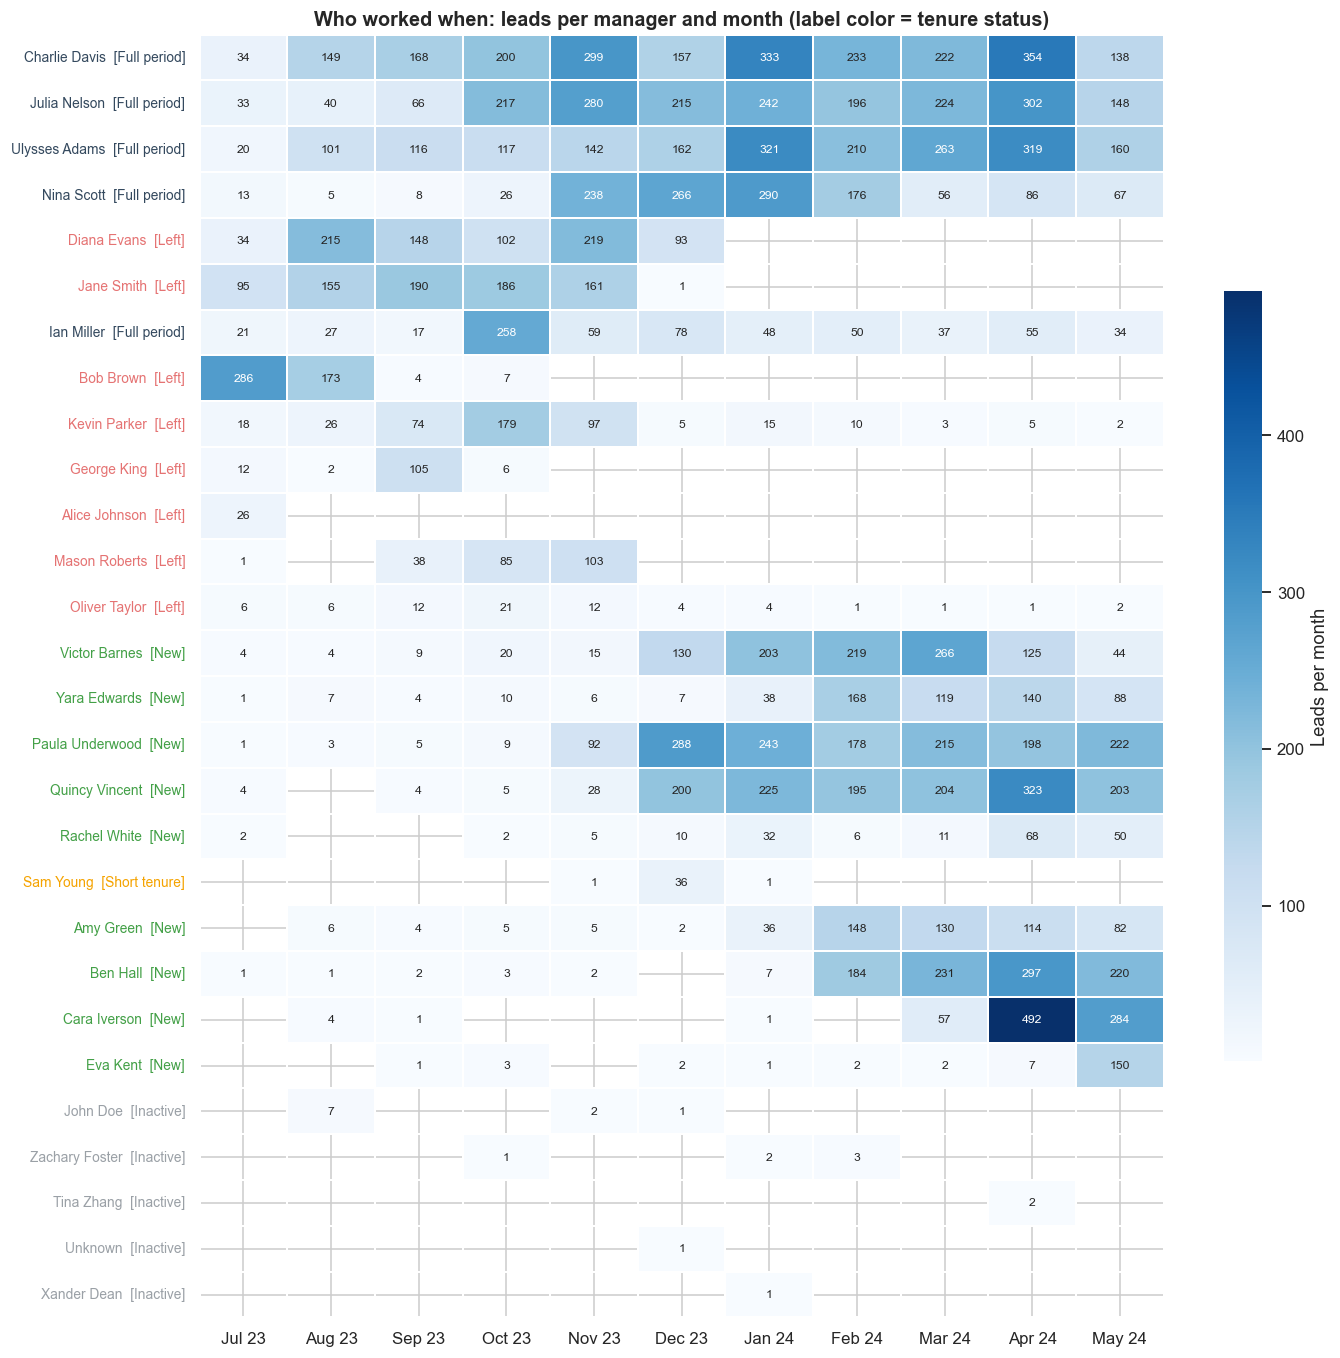

Tenure of managers in the period: **New** 9, **Left** 8, **Full period** 5, **Inactive** 5, **Short tenure** 1. Managers who joined late or left early are compared only on the months when they actually had leads.

In [17]:
# --- 6.1 Manager activity by month ---
deals['mkey'] = deals['deal_owner_name'] + '|' + deals['month'].dt.strftime('%Y-%m')
mm = deals.groupby(['deal_owner_name', 'month']).agg(leads=('is_won', 'size'), won=('is_won', 'sum'), rev=('rev_won', 'sum')).reset_index()
leads_p = mm.pivot(index='deal_owner_name', columns='month', values='leads').reindex(columns=months).fillna(0)
active = leads_p >= MIN_LEADS_MONTH

first_active = active.apply(lambda r: r.idxmax() if r.any() else pd.NaT, axis=1)
last_active = active.apply(lambda r: r[::-1].idxmax() if r.any() else pd.NaT, axis=1)

def tenure_status(first, last):
    if pd.isna(first):
        return 'Inactive'
    joined_late = first > pd.Timestamp('2023-09-01')      # first active month after Sep 2023
    left_early = last < pd.Timestamp('2024-04-01')        # no active month in Apr-May 2024
    if joined_late and left_early:
        return 'Short tenure'
    return 'New' if joined_late else ('Left' if left_early else 'Full period')

mg = pd.DataFrame({'first': first_active, 'last': last_active, 'active_months': active.sum(axis=1)})
mg['status'] = [tenure_status(f, l) for f, l in zip(mg['first'], mg['last'])]
mg['leads_total'] = leads_p.sum(axis=1)
STATUS_COL = {'Full period': COL['navy'], 'New': COL['green'], 'Left': COL['red'], 'Short tenure': COL['amber'], 'Inactive': COL['grey']}

order_m = mg.sort_values(['first', 'leads_total'], ascending=[True, False], na_position='last').index
hm = leads_p.loc[order_m]
fig, ax = plt.subplots(figsize=(13, 0.36 * len(hm) + 2.4))
sns.heatmap(hm.replace(0, np.nan), annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Leads per month', 'shrink': 0.6},
            linewidths=1, linecolor='white', ax=ax, annot_kws={'fontsize': 8}, xticklabels=labels_m)
ax.set_ylabel(''); ax.set_xlabel('')
ax.set_yticklabels([f"{n}  [{mg.loc[n, 'status']}]" for n in hm.index], fontsize=9)
for t, n in zip(ax.get_yticklabels(), hm.index):
    t.set_color(STATUS_COL[mg.loc[n, 'status']])
ax.set_title('Who worked when: leads per manager and month (label color = tenure status)')
finish(fig, '04_12_manager_activity')

cnt = mg['status'].value_counts()
say("Tenure of managers in the period: " + ', '.join(f'**{k}** {v}' for k, v in cnt.items()) + '. '
    'Managers who joined late or left early are compared only on the months when they actually had leads.')

In [18]:
# --- 6.2 Manager metrics per active month ---
act = mm[mm['leads'] >= MIN_LEADS_MONTH]
per = act.groupby('deal_owner_name').agg(leads=('leads', 'sum'), won=('won', 'sum'), rev=('rev', 'sum'),
                                         rev_med=('rev', 'median'), rev_mean=('rev', 'mean'), months=('leads', 'size'))
per['leads_pm'] = per['leads'] / per['months']
per['C1'] = per['won'] / per['leads'] * 100

# expected sales given the channel mix of the manager's leads
p_src = deals.groupby('source')['is_won'].mean()
deals['p_exp'] = deals['source'].map(p_src)
da = deals[deals['mkey'].isin(set(act['deal_owner_name'] + '|' + act['month'].dt.strftime('%Y-%m')))]
ex = da.groupby('deal_owner_name').agg(expected=('p_exp', 'sum'), var=('p_exp', lambda p: (p * (1 - p)).sum()))
per = per.join(ex)
per['index'] = per['won'] / per['expected']
per['idx_lo'] = (per['won'] - 1.96 * np.sqrt(per['var'])) / per['expected']
per['idx_hi'] = (per['won'] + 1.96 * np.sqrt(per['var'])) / per['expected']
per = per.join(mg[['status']])

# ranking only where there is enough data
ranked = per[(per['months'] >= 3) & (per['leads'] >= 150)].sort_values('rev_med', ascending=False)
team_med = ranked['rev_med'].median()
display(ranked[['status', 'months', 'leads_pm', 'rev_med', 'C1', 'index']].round(2))
print(f"Ranked managers: {len(ranked)} of {len(per)} (at least 3 active months and 150 leads)")

,status,months,leads_pm,rev_med,C1,index
deal_owner_name,,,,,,
Jane Smith,Left,5,157.40,"48,630.00",4.83,1.04
Ulysses Adams,Full period,11,175.55,"46,150.00",7.41,1.65
Paula Underwood,New,7,205.14,"45,300.91",6.62,1.44
Charlie Davis,Full period,11,207.91,"42,617.58",5.99,1.36
Julia Nelson,Full period,11,178.45,"31,960.00",5.09,1.15
Kevin Parker,Left,7,59.86,"21,110.00",6.44,1.47
Quincy Vincent,New,7,196.86,"20,800.91",4.21,0.96
Ben Hall,New,4,233.00,"17,065.45",3.97,0.86
Cara Iverson,New,3,277.67,"16,770.00",3.12,0.72


Ranked managers: 17 of 23 (at least 3 active months and 150 leads)


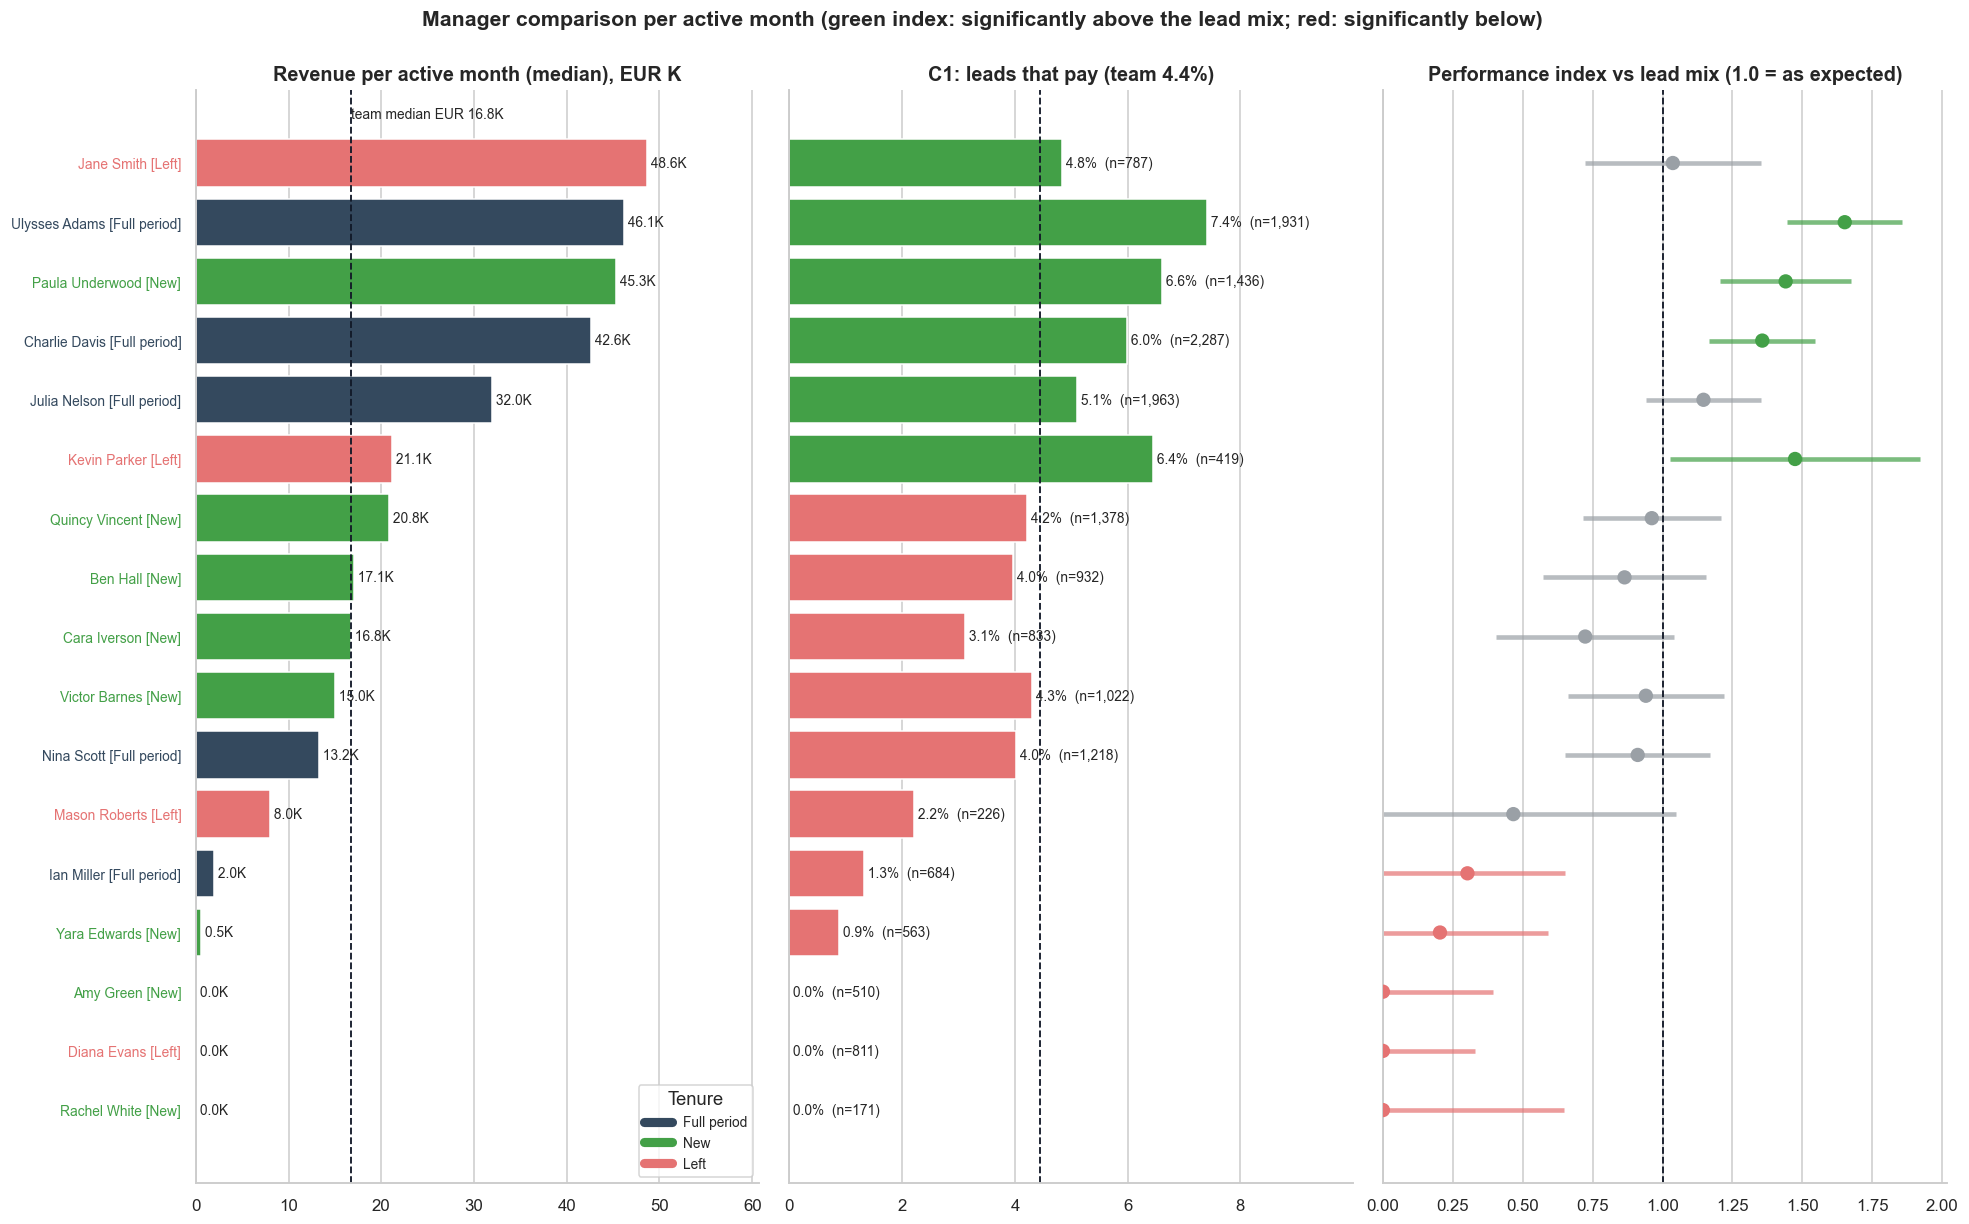

- **Strong** (index significantly above 1): Ulysses Adams, Paula Underwood, Charlie Davis, Kevin Parker.
- **Weak** (index significantly below 1): Ian Miller, Yara Edwards, Amy Green, Diana Evans, Rachel White.
- Everyone else cannot be separated from the lead-mix expectation with the data available.
- The index controls for the channel mix only, not for lead quality or response speed.

In [19]:
# --- 6.3 Ranking: scale, conversion, quality of work ---
r = ranked.iloc[::-1]          # best at the top
yy = np.arange(len(r))
fig, axes = plt.subplots(1, 3, figsize=(18, 0.5 * len(r) + 2.6), sharey=True)

ax = axes[0]
ax.barh(yy, r['rev_med'] / 1e3, color=[STATUS_COL[s] for s in r['status']])
ax.axvline(team_med / 1e3, color='#111827', ls='--', lw=1.2)
ax.text(team_med / 1e3, len(r) - 0.3, f'team median EUR {team_med / 1e3:,.1f}K', ha='left', va='bottom', fontsize=9)
for yi, v in enumerate(r['rev_med']):
    ax.text(v / 1e3, yi, f' {v / 1e3:,.1f}K', va='center', fontsize=9)
ax.set_title('Revenue per active month (median), EUR K'); ax.set_xlim(0, r['rev_med'].max() / 1e3 * 1.25)

ax = axes[1]
ax.barh(yy, r['C1'], color=[COL['green'] if v >= K['C1_leads'] else COL['red'] for v in r['C1']])
ax.axvline(K['C1_leads'], color='#111827', ls='--', lw=1.2)
for yi, (v, n) in enumerate(zip(r['C1'], r['leads'])):
    ax.text(v, yi, f' {v:.1f}%  (n={n:,.0f})', va='center', fontsize=9)
ax.set_title(f"C1: leads that pay (team {K['C1_leads']:.1f}%)"); ax.set_xlim(0, r['C1'].max() * 1.35)

ax = axes[2]
good = r['idx_lo'] > 1; bad = r['idx_hi'] < 1
cols_i = [COL['green'] if g else (COL['red'] if b else COL['grey']) for g, b in zip(good, bad)]
ax.hlines(yy, r['idx_lo'], r['idx_hi'], color=cols_i, lw=3, alpha=0.7)
ax.scatter(r['index'], yy, color=cols_i, s=70, zorder=3)
ax.axvline(1, color='#111827', ls='--', lw=1.2)
ax.set_title('Performance index vs lead mix (1.0 = as expected)')
ax.set_xlim(0, max(r['idx_hi'].max() * 1.05, 1.5))

axes[0].set_yticks(yy); axes[0].set_yticklabels([f"{n} [{s}]" for n, s in zip(r.index, r['status'])], fontsize=9)
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([0], [0], color=STATUS_COL[k], lw=6, label=k) for k in ['Full period', 'New', 'Left', 'Short tenure'] if k in set(r['status'])],
               loc='lower right', frameon=True, fontsize=9, title='Tenure')
for t, s in zip(axes[0].get_yticklabels(), r['status']):
    t.set_color(STATUS_COL[s])
for a in axes:
    a.grid(axis='y', visible=False)
fig.suptitle('Manager comparison per active month (green index: significantly above the lead mix; red: significantly below)', fontsize=14, fontweight='bold', y=1.0)
finish(fig, '04_13_manager_ranking')

strong = ranked[ranked['idx_lo'] > 1].index.tolist()
weak = ranked[ranked['idx_hi'] < 1].index.tolist()
say(f"- **Strong** (index significantly above 1): {', '.join(strong) if strong else 'none'}.\n"
    f"- **Weak** (index significantly below 1): {', '.join(weak) if weak else 'none'}.\n"
    f"- Everyone else cannot be separated from the lead-mix expectation with the data available.\n"
    f"- The index controls for the channel mix only, not for lead quality or response speed.")

In [20]:
# --- 6.4 Managers without sales ---
tot = deals.groupby('deal_owner_name').agg(leads=('is_won', 'size'), won=('is_won', 'sum'))
zero = tot[tot['won'] == 0].sort_values('leads', ascending=False)
top4 = deals.groupby('deal_owner_name')['rev_won'].sum().nlargest(4)
say(f"- **{len(zero)} managers closed no sale** but received {zero['leads'].sum():,} leads ({zero['leads'].sum() / len(deals) * 100:.1f}% of the flow). "
    f"The largest: {', '.join(f'{n} ({v:,})' for n, v in zero['leads'].head(3).items())}. Check their role: qualification, support or inactive accounts?\n"
    f"- The top 4 managers bring **{top4.sum() / K['REV'] * 100:.0f}%** of revenue: a concentration risk if one of them leaves.")

- **10 managers closed no sale** but received 1,613 leads (8.8% of the flow). The largest: Diana Evans (811), Amy Green (532), Rachel White (186). Check their role: qualification, support or inactive accounts?
- The top 4 managers bring **59%** of revenue: a concentration risk if one of them leaves.

---
# 7. Where to act
**Question:** which lever moves contribution margin most, and how fast can we see the result?

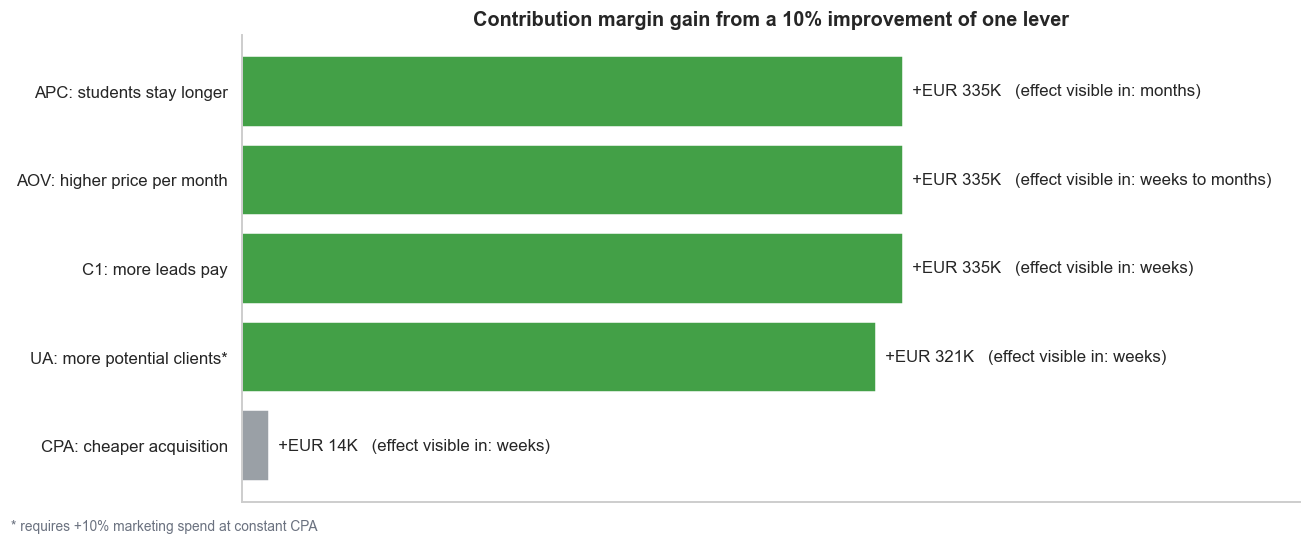

Conversion, price and duration are equally large (+10% = **EUR 335K**), but conversion reacts in weeks and needs no extra ad budget. A 15% relative uplift of C1 means about **122 more students** and **EUR 502K** of revenue at constant spend (upper bound, COGS = 0).

In [21]:
# --- 7.1 Sensitivity of contribution margin ---
def cm_model(UA, C1, AOV, APC, CPA):
    """CM = UA x (LTV - CPA), LTV = C1 x AOV x APC (COGS = 0). C1 in %."""
    return UA * (C1 / 100 * AOV * APC - CPA)

base = dict(UA=K['UA'], C1=K['C1'], AOV=K['AOV'], APC=K['APC'], CPA=K['CPA'])
cm0 = cm_model(**base)
levers = [('C1: more leads pay', 'C1', 0.10, 'weeks'), ('AOV: higher price per month', 'AOV', 0.10, 'weeks to months'),
          ('APC: students stay longer', 'APC', 0.10, 'months'), ('UA: more potential clients*', 'UA', 0.10, 'weeks'),
          ('CPA: cheaper acquisition', 'CPA', -0.10, 'weeks')]
rows = []
for label, key, chg, speed in levers:
    p = dict(base); p[key] *= (1 + chg)
    rows.append((label, cm_model(**p) - cm0, speed))
lv = pd.DataFrame(rows, columns=['lever', 'gain', 'speed']).sort_values('gain')

fig, ax = plt.subplots(figsize=(12, 4.8))
bars = ax.barh(lv['lever'], lv['gain'] / 1e3, color=[COL['green'] if g > 100e3 else COL['grey'] for g in lv['gain']])
for yi, (g, s_) in enumerate(zip(lv['gain'], lv['speed'])):
    ax.text(g / 1e3, yi, f'  +EUR {g / 1e3:,.0f}K   (effect visible in: {s_})', va='center', fontsize=11)
ax.set_xlim(0, lv['gain'].max() / 1e3 * 1.6); ax.set_xticks([]); ax.grid(False)
ax.set_title('Contribution margin gain from a 10% improvement of one lever')
fig.text(0.01, -0.02, '* requires +10% marketing spend at constant CPA', fontsize=9, color='#6B7280')
finish(fig, '04_14_levers')

base_gain15 = K['REV'] * 0.15
say(f"Conversion, price and duration are equally large (+10% = **{eur(K['REV'] * 0.10)}**), but conversion reacts in weeks and needs no extra ad budget. "
    f"A 15% relative uplift of C1 means about **{K['B'] * 0.15:,.0f} more students** and **{eur(base_gain15)}** of revenue at constant spend (upper bound, COGS = 0).")

---
# 8. Conclusions and next steps

| # | Finding | Evidence | Action | Metric in the tree |
| :--- | :--- | :--- | :--- | :--- |
| 1 | Unit economics are strong | CLTV / CAC = 24; ROMI 2,323%; marketing is 4.1% of revenue | Protect the budget; do not optimize acquisition cost first | CM, CPA |
| 2 | Conversion is the main lever | C1 of leads is 4.4%; channels range from 1.8% (CRM base) to 9.6% (Organic) | Fix the process after the lead is created | C1 |
| 3 | Google Ads is the costliest channel | 38.5% of the budget, 21% of revenue, CAC EUR 327 vs EUR 163 for Facebook | Review targeting and lead forms; re-allocate budget gradually | CPA, CAC |
| 4 | Response speed is slow and uneven | See Section 4: median first response in hours, share of leads never called | Pilot the 30-minute first-contact rule (A/B test in notebook 03) | C1 |
| 5 | Team performance is uneven | Top 4 managers: 59% of revenue; 9 managers with no sales hold 8.8% of leads | Route more good leads to proven managers; clarify roles of managers without sales | C1, B |
| 6 | Lead quality fell from 2024 while volume grew | Qualified (A-C) share: 38.8% (Aug-Nov) -> 25.8% (Dec-Mar), about 20% in Feb-May; leads +50% | Check lead sources and the rating process; protect manager time for qualified leads | C1, B |
| 7 | Data gaps limit decisions | No COGS; part of revenue has no campaign tag; German level known for 8% of leads | Add cost of delivery, mandatory UTM and lead-form fields | Profit |

**Next step:** run the randomized 14-day response-time test described in notebook 03 (Section 5) on Facebook and Google leads, read the leading indicator (share of qualified leads) after two weeks and confirm payments on the same cohorts at day 45-60.

---
# Appendix: definitions and data notes
* **Period:** 2023-07-01 to 2024-05-31 (common period of all datasets). Spend after 31 May 2024 is excluded.
* **Lead** = CRM deal (18,250). **UA** = unique potential clients from contacts (17,250). **C1 (leads)** = paying students / leads, used for channels and managers; **C1 (metrics tree)** = students / UA = 4.70%.
* **Paying student (B)** = unique `contact_id` with stage `Payment Done` and months of study > 0 (810). **T** = paid months (4,540). **AOV** = Rev / T. **APC** = T / B. **CLTV** = Rev / B.
* **Revenue (Ri)** is the accumulated revenue of a student; in monthly charts it is attributed to the month in which the lead was created (cohort view).
* **Channel** = `source` (top 10 by revenue, rest = `Other`). Set `DIM = 'campaign'` to run the same analysis on campaigns.
* **Months of study (T)** behave like months studied up to the data cutoff: the average falls from 9.7 (leads of August 2023) to 1.9 (leads of May 2024) while the course length stays at 10-11 months. Revenue, T and APC of recent cohorts are therefore still accumulating, and CLTV is a lower bound of lifetime revenue. Confirm the definition of the source field.
* **COGS** is not available and is set to 0: CLTV, LTV and CM are revenue-based upper bounds.